# PowerClient Churn Analysis

# Exploratory Data Analysis



1. Import packages
2. Load data with Pandas
3. Descriptive statistics
4. Visual exploration




## 1. Plotting and data tooling

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook display behavior
%matplotlib inline

# For consistent default style across plots
sns.set(color_codes=True)


## 2. Load data with Pandas

Loading `client_data.csv` and `price_data.csv` into separate dataframes to inspect structure and quality.

In [3]:
client_df = pd.read_csv("./client_data.csv")
price_df = pd.read_csv("./price_data.csv")

Quick spot check of the first rows to validate file read, column names, and basic formatting.

In [7]:
#Previewing client data
display(client_df.head(3))

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


In [8]:
#Previewing price data
display(price_df.head(3))

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


In [9]:
# Schema overview
client_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [10]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


## 3. Summary statistics

Reviewing distribution indicators (such percentiles, mean vs median) and check for suspicious ranges (e.g., many zeros).

In [15]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [16]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


## 4. Visual exploration

Defining reusable plotting utilities first.



In [17]:
from typing import Optional, Tuple

def annotate_stacked_bars(ax, pad: float = 0.99, color: str = "white", textsize: int = 13) -> None:
    """Add value labels centered within each stacked bar segment (skip zeros)."""
    for patch in ax.patches:
        height = patch.get_height()
        if height == 0:
            continue

        label = str(round(height, 1))
        x = ((patch.get_x() + patch.get_width() / 2) * pad) - 0.05
        y = (patch.get_y() + height / 2) * pad

        ax.annotate(label, (x, y), color=color, size=textsize)

def plot_stacked_bars(
    dataframe: pd.DataFrame,
    title: str,
    size: Tuple[int, int] = (18, 10),
    rot: int = 0,
    legend_loc: str = "upper right",
    y_label: str = "Company base (%)",
    legend_labels: Tuple[str, str] = ("Retention", "Churn"),
) -> None:
    """Plot stacked bar chart and label segments for quick comparison of churn composition."""
    ax = dataframe.plot(kind="bar", stacked=True, figsize=size, rot=rot, title=title)
    annotate_stacked_bars(ax, textsize=14)
    ax.set_ylabel(y_label)
    ax.legend(list(legend_labels), loc=legend_loc)
    plt.show()


### Churn

Computing overall churn split, expressed as a percentage of total companies.


In [18]:
#Overall churn percentages
churn_view = client_df[["id", "churn"]].copy()
churn_view.columns = ["Companies", "churn"]

churn_counts = churn_view.groupby("churn")["Companies"].count()
churn_percentage = (churn_counts / churn_counts.sum() * 100).to_frame().T  # shape aligned for stacked bars
churn_percentage

churn,0,1
Companies,90.284814,9.715186


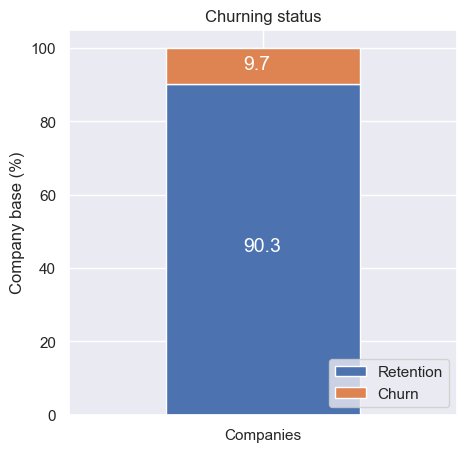

In [19]:
# Plotting churn split
plot_stacked_bars(churn_percentage, "Churning status", size=(5, 5), legend_loc="lower right")

### Sales channel

Computing churn rate distribution per sales channel to see if churn concentrates in specific acquisition paths.

In [20]:
# Channel churn table (%)
channel_view = client_df[["id", "channel_sales", "churn"]].copy()

channel_counts = (
    channel_view
    .groupby(["channel_sales", "churn"])["id"]
    .count()
    .unstack(level=1)
    .fillna(0)
)

channel_churn_pct = (channel_counts.div(channel_counts.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)
channel_churn_pct


churn,0,1
channel_sales,,
foosdfpfkusacimwkcsosbicdxkicaua,87.859046,12.140954
usilxuppasemubllopkaafesmlibmsdf,89.963636,10.036364
ewpakwlliwisiwduibdlfmalxowmwpci,91.601344,8.398656
MISSING,92.402685,7.597315
lmkebamcaaclubfxadlmueccxoimlema,94.411286,5.588714
epumfxlbckeskwekxbiuasklxalciiuu,100.000000,0.000000
fixdbufsefwooaasfcxdxadsiekoceaa,100.000000,0.000000
sddiedcslfslkckwlfkdpoeeailfpeds,100.000000,0.000000


`MISSING` is an important channel. We will further explore later.

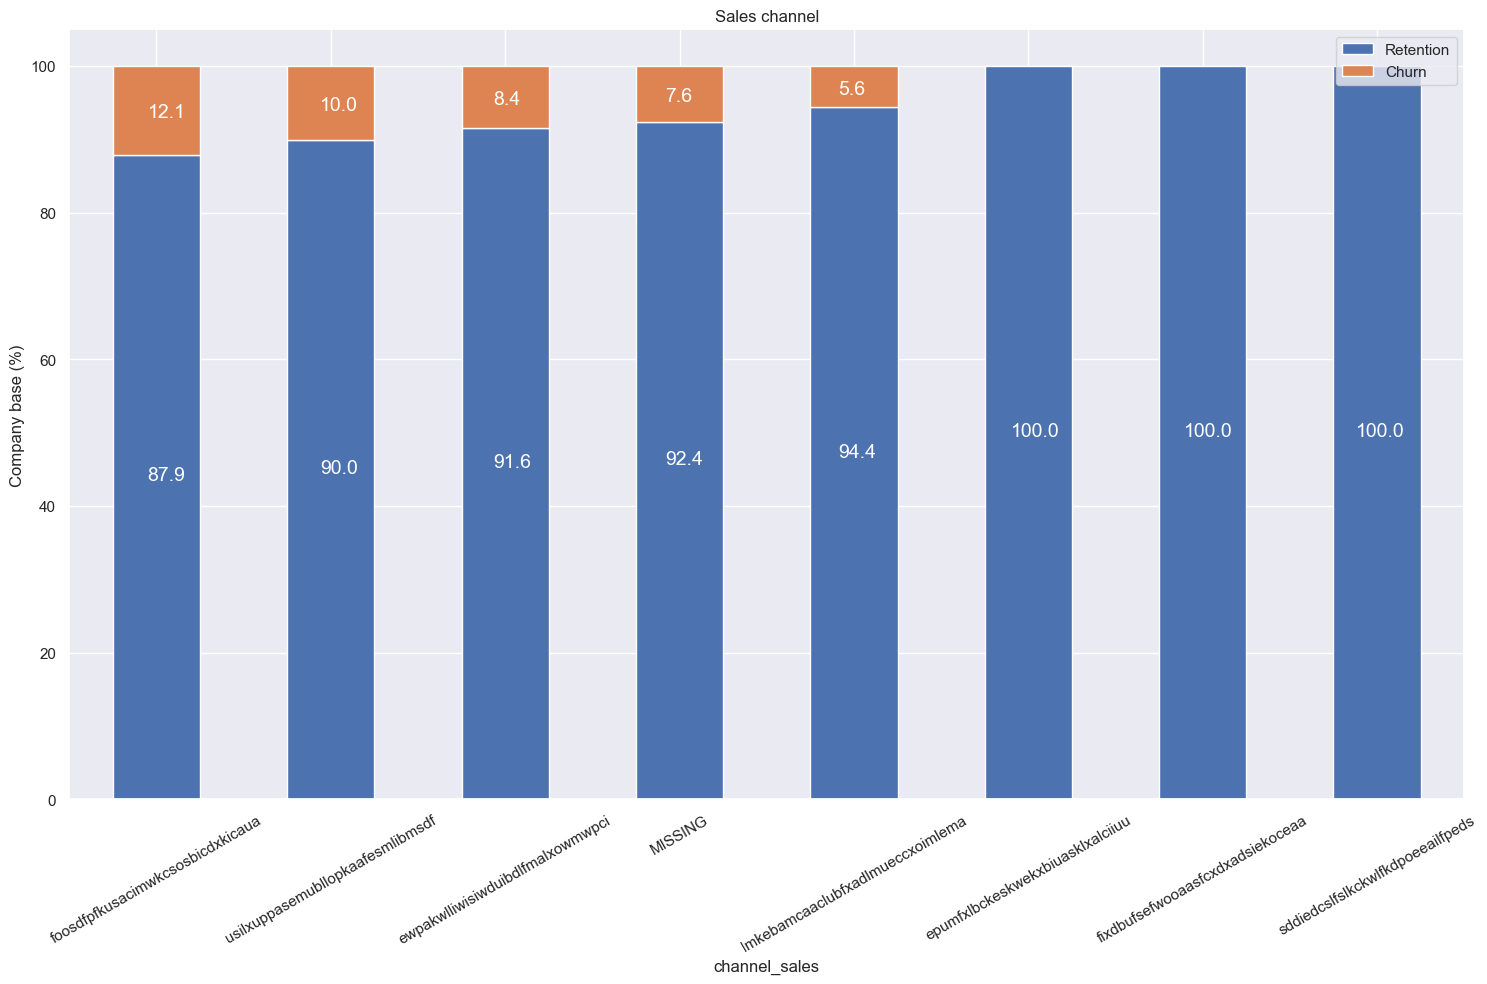

In [21]:
# Plotting channel churn
plot_stacked_bars(channel_churn_pct, "Sales channel", rot=30)

### Consumption

Plotting churn vs retention distributions to identify key consumption variables, then using boxplots to confirm outlier structure.s

In [22]:
# Consumption subset
consumption = client_df[[
    "id",
    "cons_12m",
    "cons_gas_12m",
    "cons_last_month",
    "imp_cons",
    "has_gas",
    "churn",
]].copy()
consumption.head(3)

,id,cons_12m,cons_gas_12m,cons_last_month,imp_cons,has_gas,churn
0,24011ae4ebbe3035111d65fa7c15bc57,0,54946,0,0.0,t,1
1,d29c2c54acc38ff3c0614d0a653813dd,4660,0,0,0.0,f,0
2,764c75f661154dac3a6c254cd082ea7d,544,0,0,0.0,f,0


In [23]:
consumption.describe()

,cons_12m,cons_gas_12m,cons_last_month,imp_cons,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,152.786896,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,341.369366,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,0.000000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,37.395000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,193.980000,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,15042.790000,1.000000


In [24]:
# Distribution plotting helper
def plot_distribution(dataframe: pd.DataFrame, column: str, ax, bins: int = 50) -> None:
    """Stacked histogram comparing retention vs churn for a single numeric variable."""
    temp = pd.DataFrame({
        "Retention": dataframe.loc[dataframe["churn"] == 0, column],
        "Churn": dataframe.loc[dataframe["churn"] == 1, column],
    })
    temp[["Retention", "Churn"]].plot(kind="hist", bins=bins, stacked=True, ax=ax)
    ax.set_xlabel(column)
    ax.ticklabel_format(style="plain", axis="x")


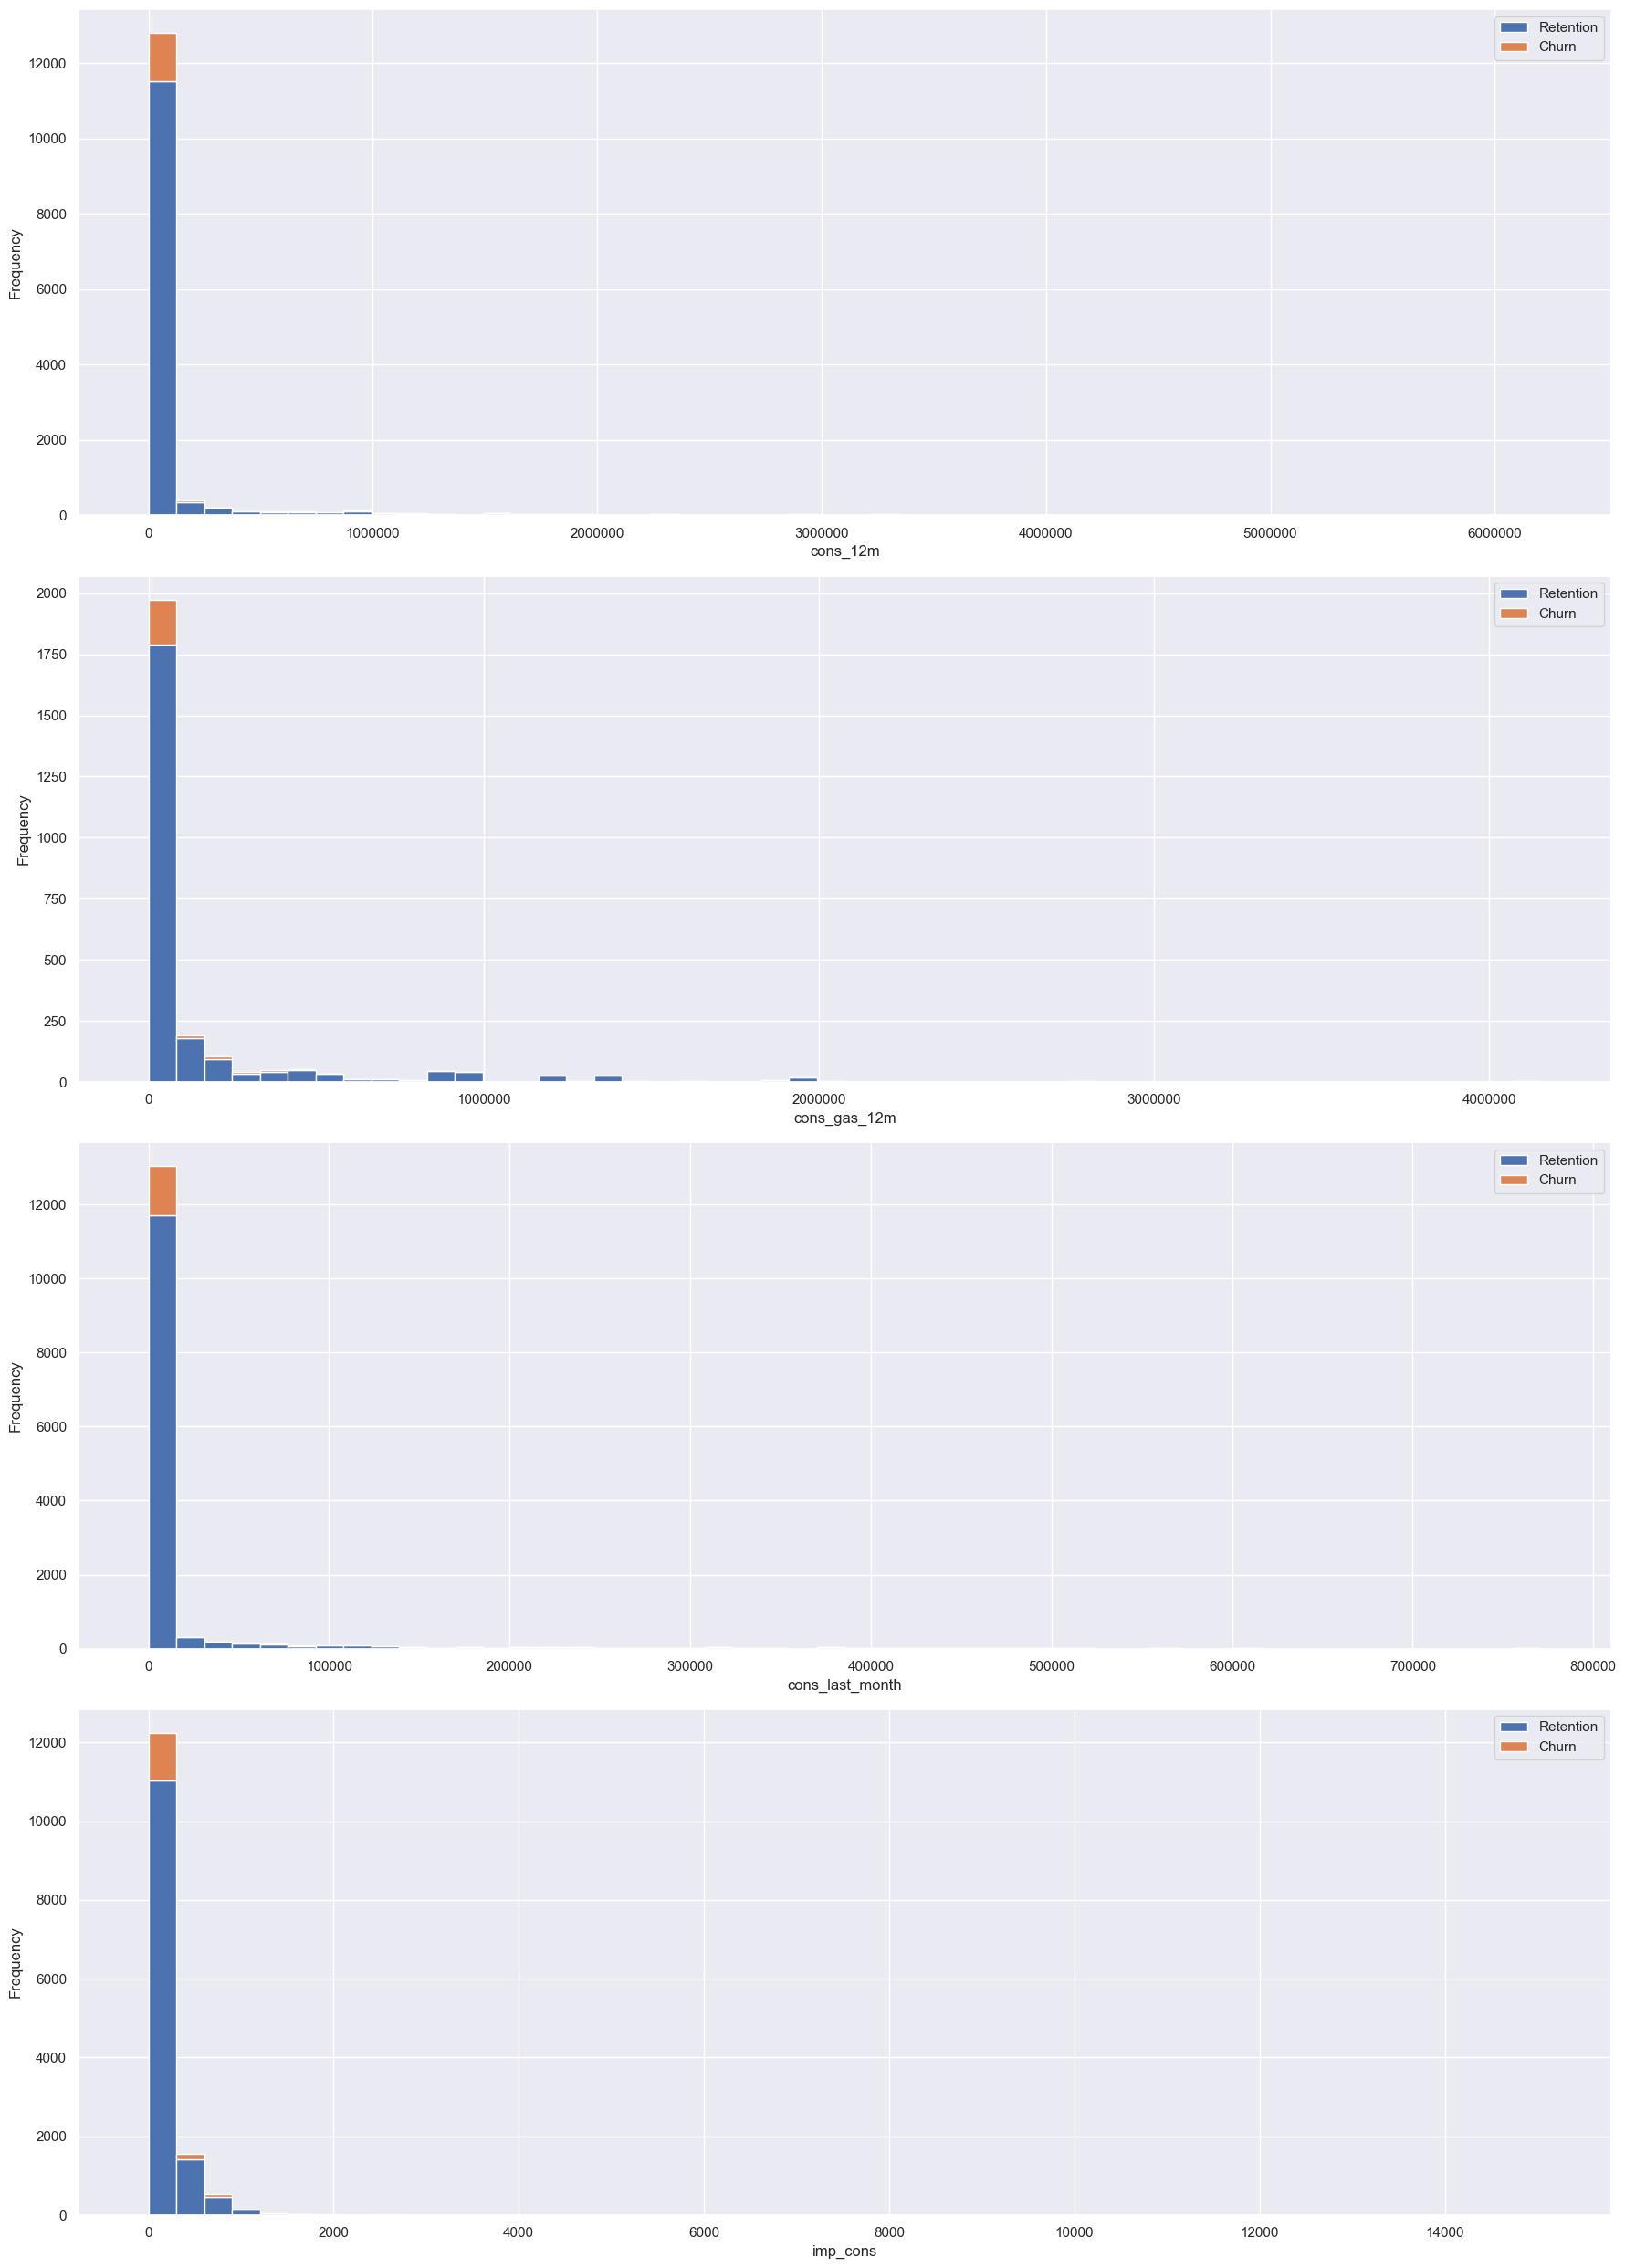

In [27]:
#  Histograms
fig, axs = plt.subplots(nrows=4, figsize=(18, 25))

plot_distribution(consumption, "cons_12m", axs[0])
plot_distribution(consumption.loc[consumption["has_gas"] == "t"], "cons_gas_12m", axs[1])
plot_distribution(consumption, "cons_last_month", axs[2])
plot_distribution(consumption, "imp_cons", axs[3])

plt.tight_layout()
plt.show()


As can be seen above, data is heavily right skewed

**Boxplots** to get a direct read on outlier magnitude and how far the right tail extends for each consumption measure.


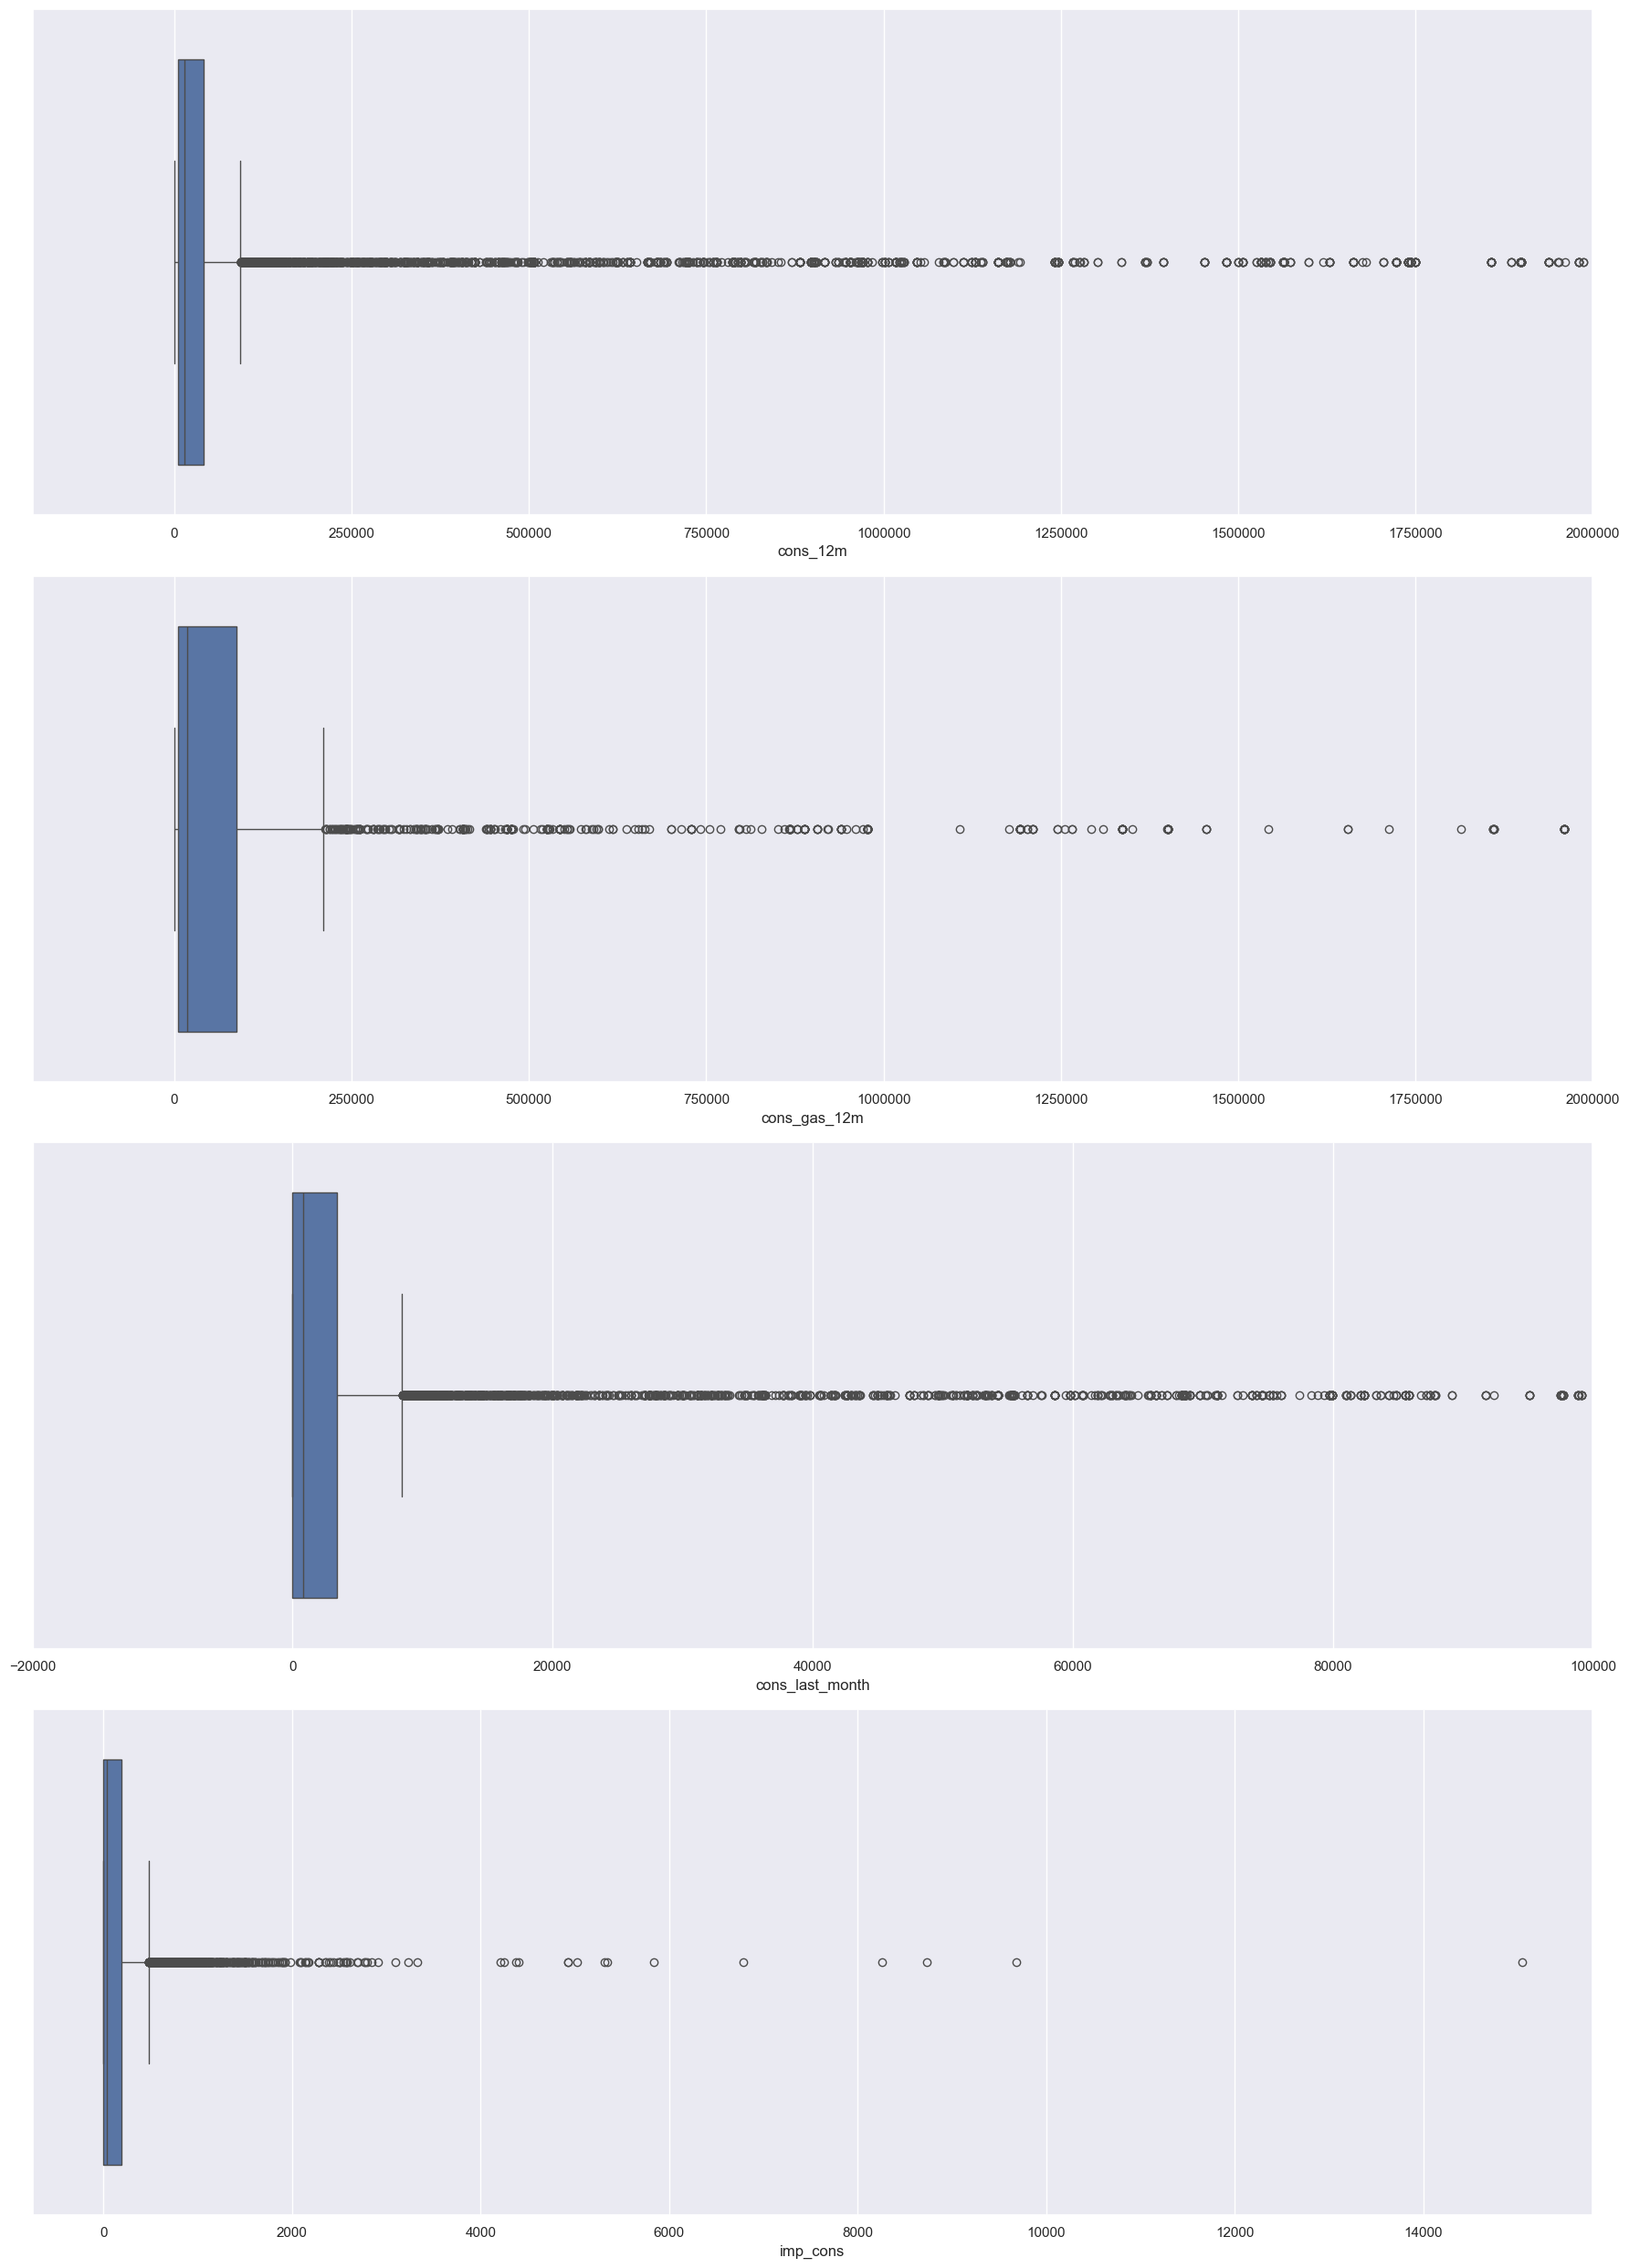

In [29]:
#  Boxplots - consumption
fig, axs = plt.subplots(nrows=4, figsize=(18, 25))

sns.boxplot(x=consumption["cons_12m"], ax=axs[0])
sns.boxplot(x=consumption.loc[consumption["has_gas"] == "t", "cons_gas_12m"], ax=axs[1])
sns.boxplot(x=consumption["cons_last_month"], ax=axs[2])
sns.boxplot(x=consumption["imp_cons"], ax=axs[3])

for ax in axs:
    ax.ticklabel_format(style="plain", axis="x")

# Keeping the same axis limits as used previously to make comparison stable
axs[0].set_xlim(-200000, 2000000)
axs[1].set_xlim(-200000, 2000000)
axs[2].set_xlim(-20000, 100000)

plt.tight_layout()
plt.show()


As expected, there are many large outliers 

### Forecast variables

Repeating the same churn-vs-retention distribution check for forecast-related predictors.


In [31]:
# Forecast subset
forecast = client_df[[
    "id",
    "forecast_cons_12m",
    "forecast_cons_year",
    "forecast_discount_energy",
    "forecast_meter_rent_12m",
    "forecast_price_energy_off_peak",
    "forecast_price_energy_peak",
    "forecast_price_pow_off_peak",
    "churn",
]].copy()

forecast.head(3)


,id,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,1
1,d29c2c54acc38ff3c0614d0a653813dd,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,0
2,764c75f661154dac3a6c254cd082ea7d,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,0


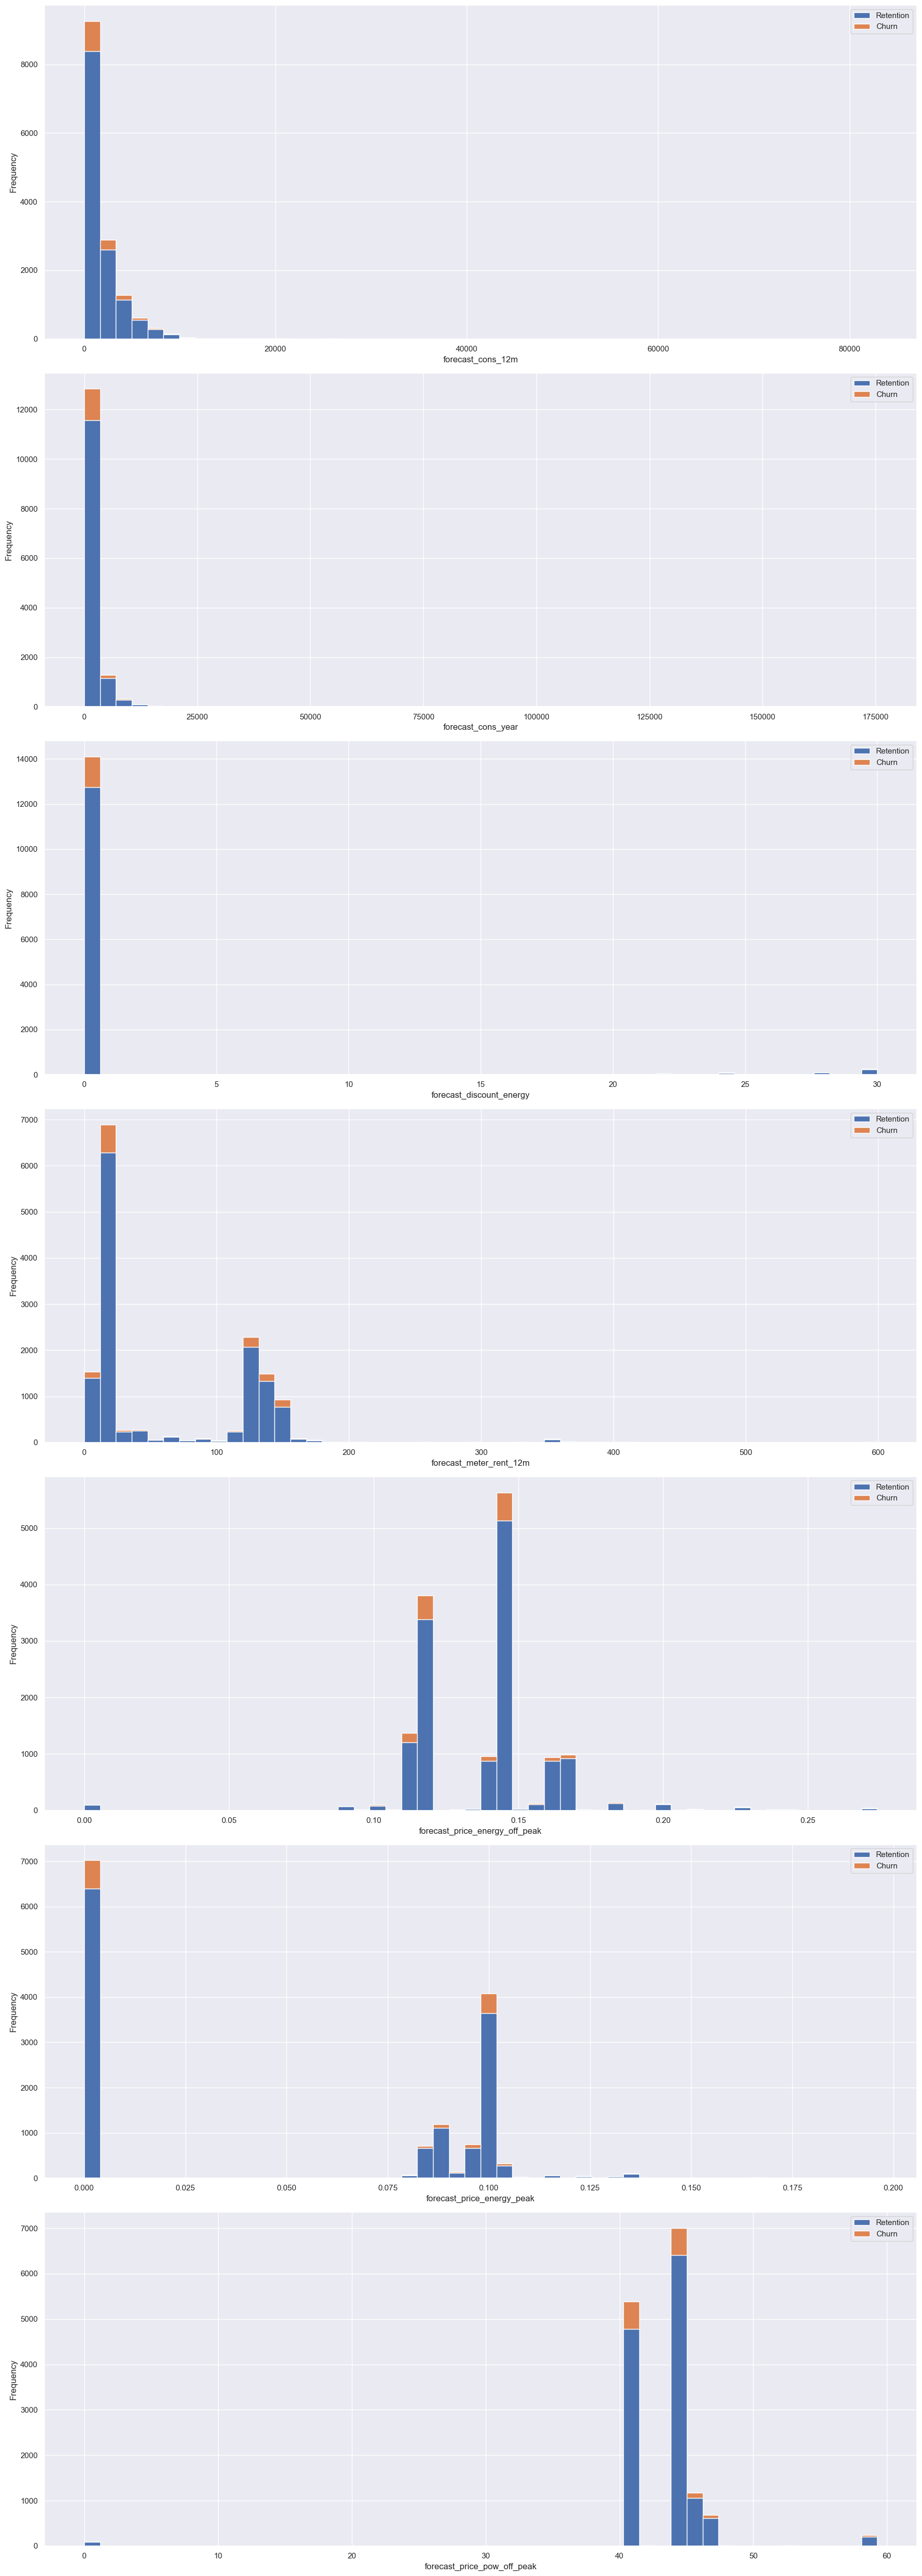

In [32]:
# Forecast histograms
fig, axs = plt.subplots(nrows=7, figsize=(18, 50))

plot_distribution(client_df, "forecast_cons_12m", axs[0])
plot_distribution(client_df, "forecast_cons_year", axs[1])
plot_distribution(client_df, "forecast_discount_energy", axs[2])
plot_distribution(client_df, "forecast_meter_rent_12m", axs[3])
plot_distribution(client_df, "forecast_price_energy_off_peak", axs[4])
plot_distribution(client_df, "forecast_price_energy_peak", axs[5])
plot_distribution(client_df, "forecast_price_pow_off_peak", axs[6])

plt.tight_layout()
plt.show()


### Contract type (has gas)

Compare churn rate for gas vs non-gas contracts using stacked percentages.


In [33]:
# Contract churn table (%)
contract_view = client_df[["id", "has_gas", "churn"]].copy()

contract_counts = (
    contract_view
    .groupby(["churn", "has_gas"])["id"]
    .count()
    .unstack(level=0)
)

contract_percentage = (contract_counts.div(contract_counts.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)
contract_percentage


churn,0,1
has_gas,,
f,89.945629,10.054371
t,91.814410,8.185590


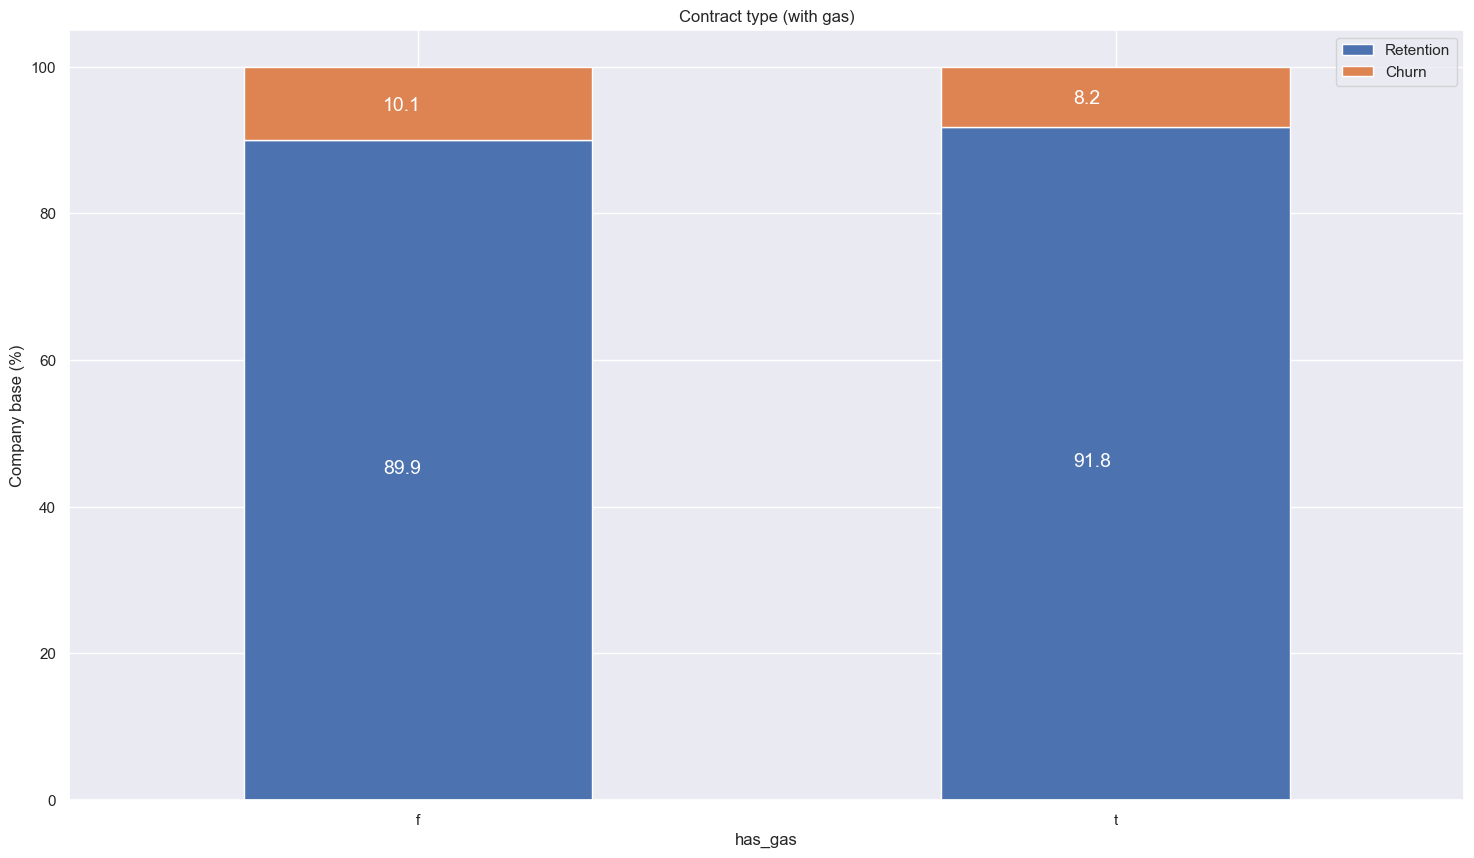

In [34]:
# Plottimg contract churn
plot_stacked_bars(contract_percentage, "Contract type (with gas)")

### Margins

Margins should be checked for extreme outliers because they can dominate tree based splits (once I use RF later) and distort interpretation.

In [35]:
# Margin subset
margin = client_df[["id", "margin_gross_pow_ele", "margin_net_pow_ele", "net_margin"]].copy()
margin.head(3)


,id,margin_gross_pow_ele,margin_net_pow_ele,net_margin
0,24011ae4ebbe3035111d65fa7c15bc57,25.44,25.44,678.99
1,d29c2c54acc38ff3c0614d0a653813dd,16.38,16.38,18.89
2,764c75f661154dac3a6c254cd082ea7d,28.60,28.60,6.60


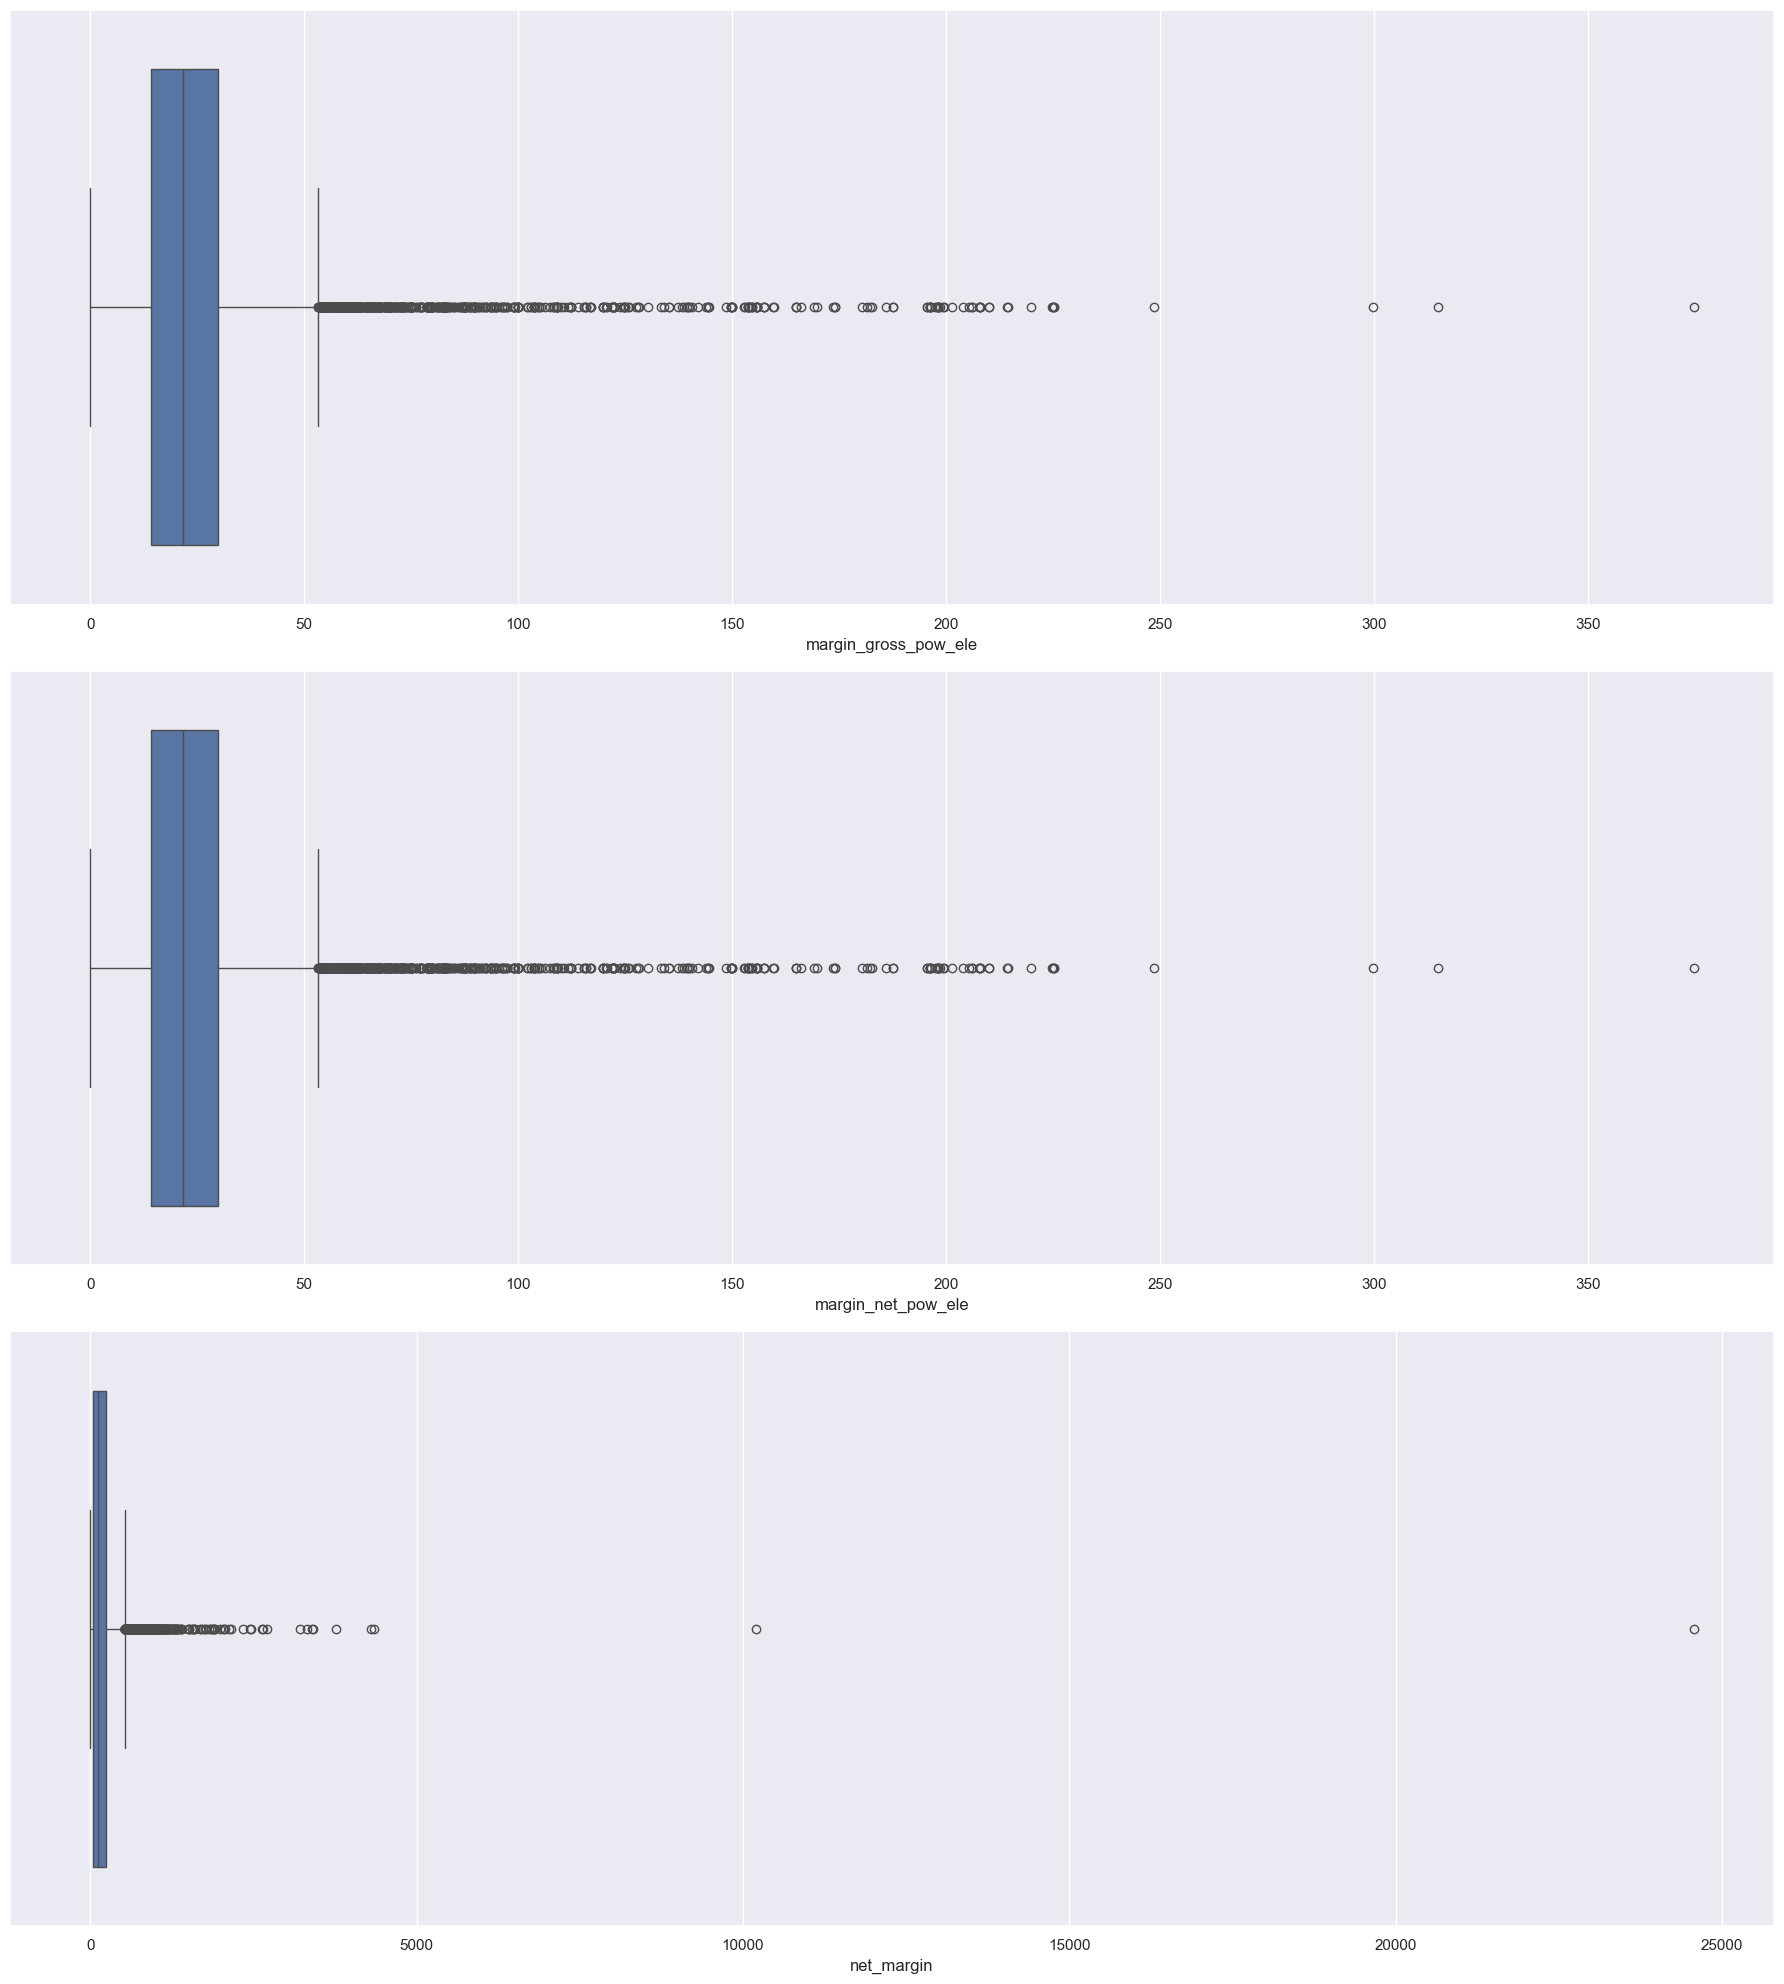

In [36]:
# Margin boxplots
fig, axs = plt.subplots(nrows=3, figsize=(18, 20))

sns.boxplot(x=margin["margin_gross_pow_ele"], ax=axs[0])
sns.boxplot(x=margin["margin_net_pow_ele"], ax=axs[1])
sns.boxplot(x=margin["net_margin"], ax=axs[2])

for ax in axs:
    ax.ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()


### Subscribed power

Checking whether max subscribed power differs systematically between churners and non-churners.


In [37]:
# Power subset
power = client_df[["id", "pow_max", "churn"]].copy()
power.head(3)


,id,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,13.856,0


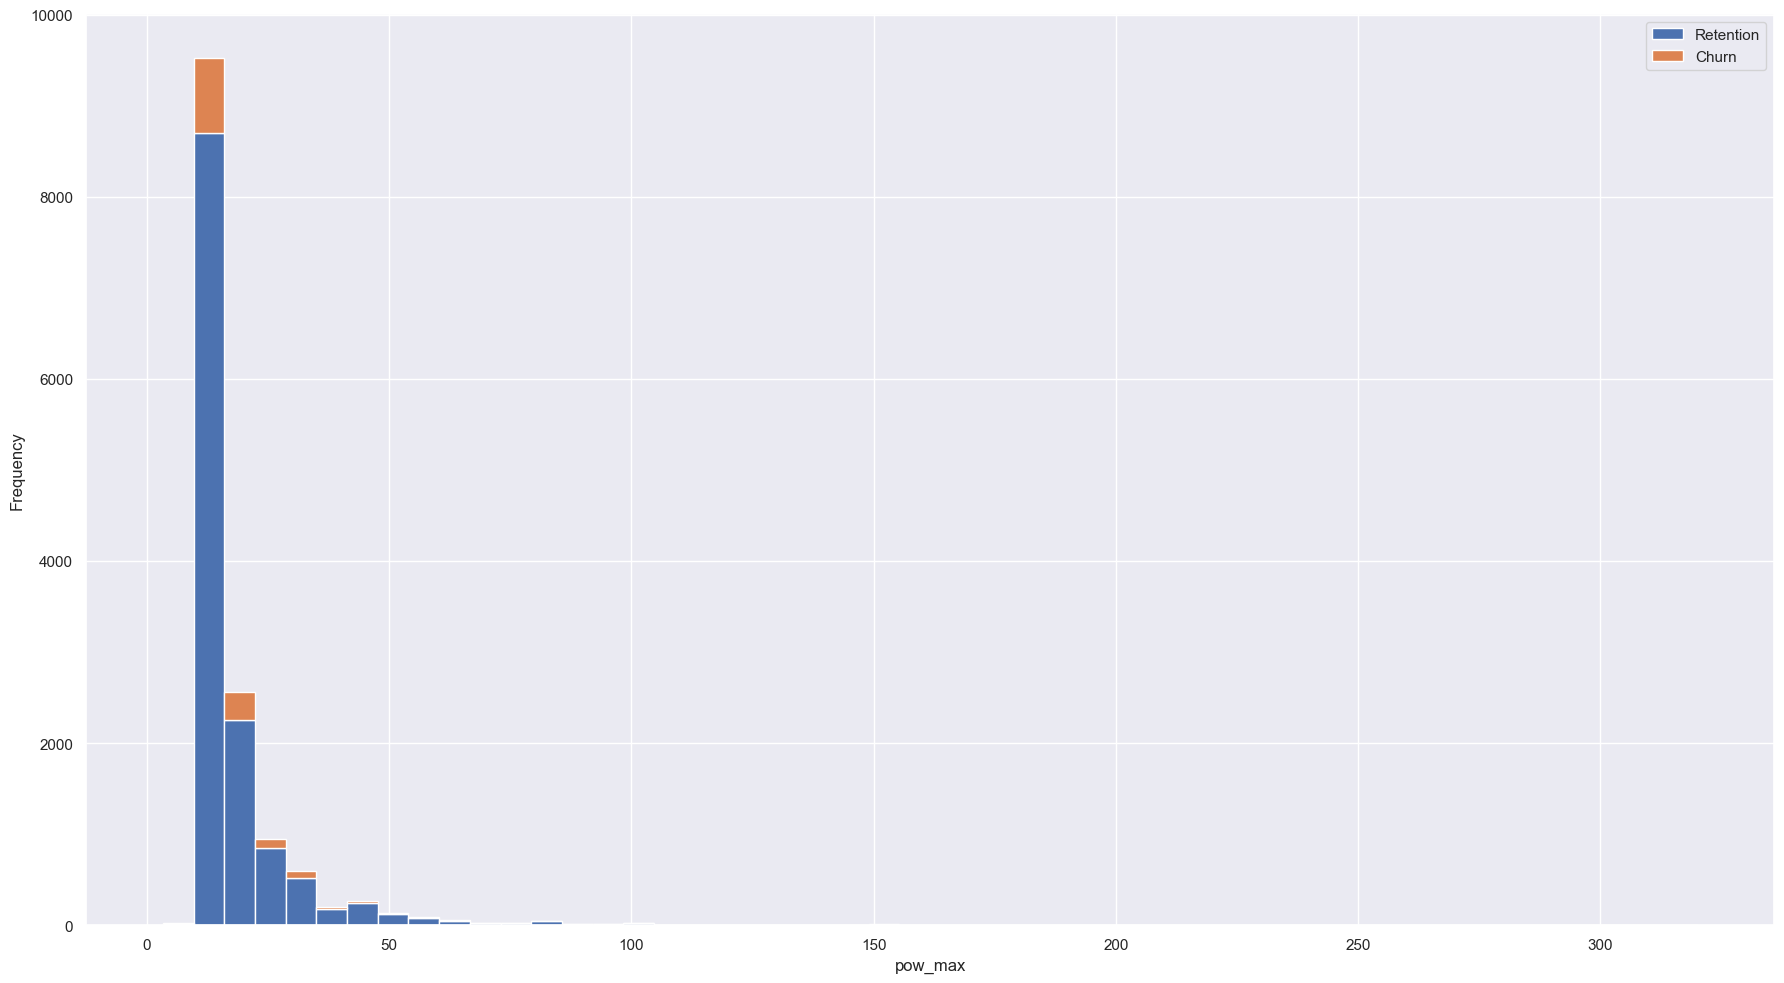

In [38]:
# Power distribution
fig, ax = plt.subplots(nrows=1, figsize=(18, 10))
plot_distribution(power, "pow_max", ax)
plt.tight_layout()
plt.show()


### Other columns

Inspecting churn composition across number of active products, customer tenure proxy (like `num_years_antig`), and origin of contract.

In [39]:
# Other subset and product count churn %
others = client_df[["id", "nb_prod_act", "num_years_antig", "origin_up", "churn"]].copy()

products_counts = (
    others
    .groupby(["nb_prod_act", "churn"])["id"]
    .count()
    .unstack(level=1)
)

products_percentage = (products_counts.div(products_counts.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)
products_percentage


churn,0,1
nb_prod_act,,
4,90.000000,10.000000
1,90.018371,9.981629
3,90.057361,9.942639
5,90.322581,9.677419
2,91.492843,8.507157
6,100.000000,NaN
8,100.000000,NaN
9,100.000000,NaN
10,100.000000,NaN


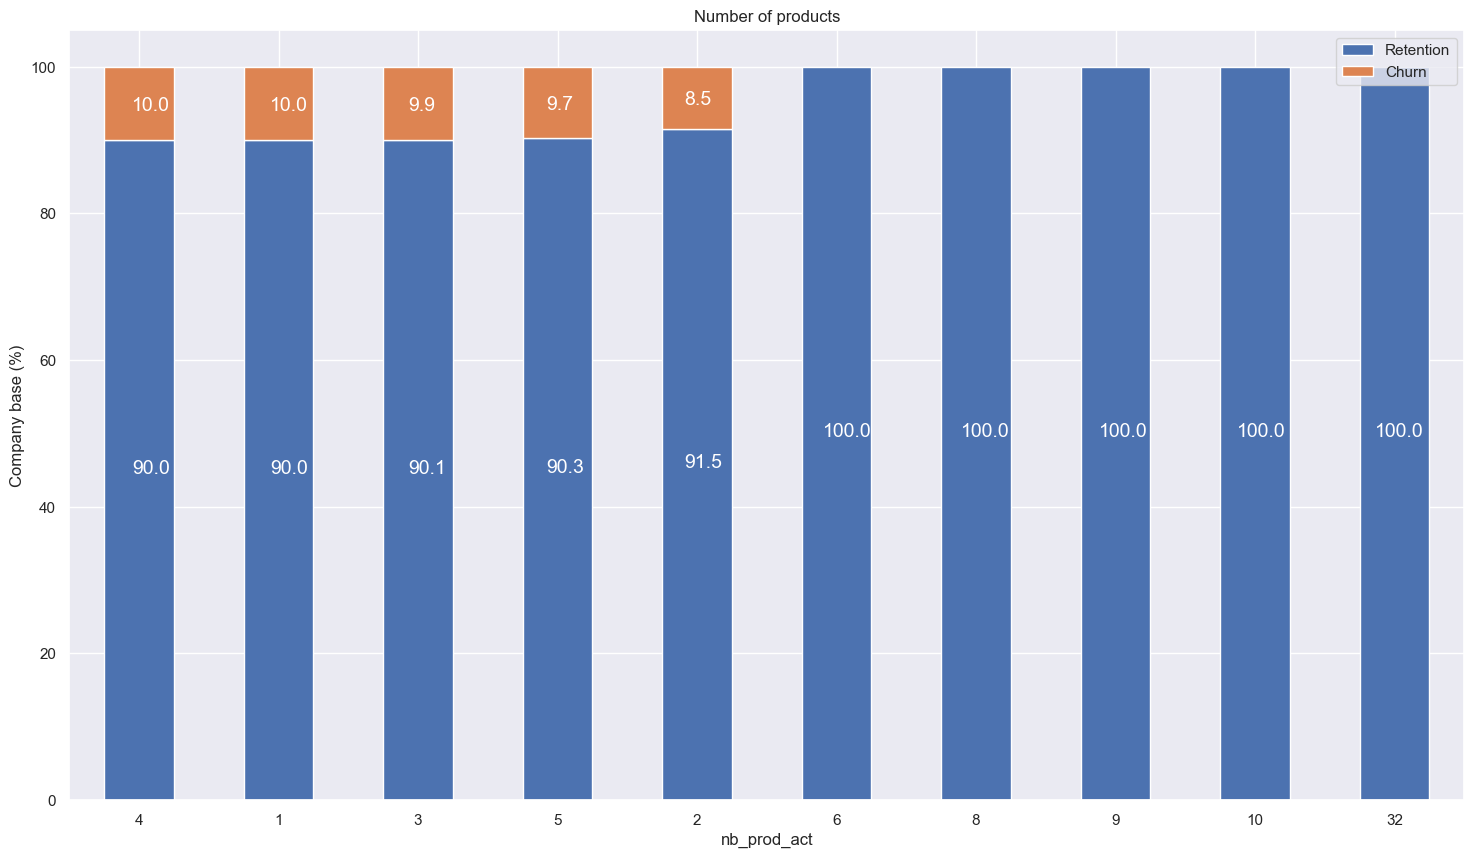

In [40]:
# Plotting number of products
plot_stacked_bars(products_percentage, "Number of products")

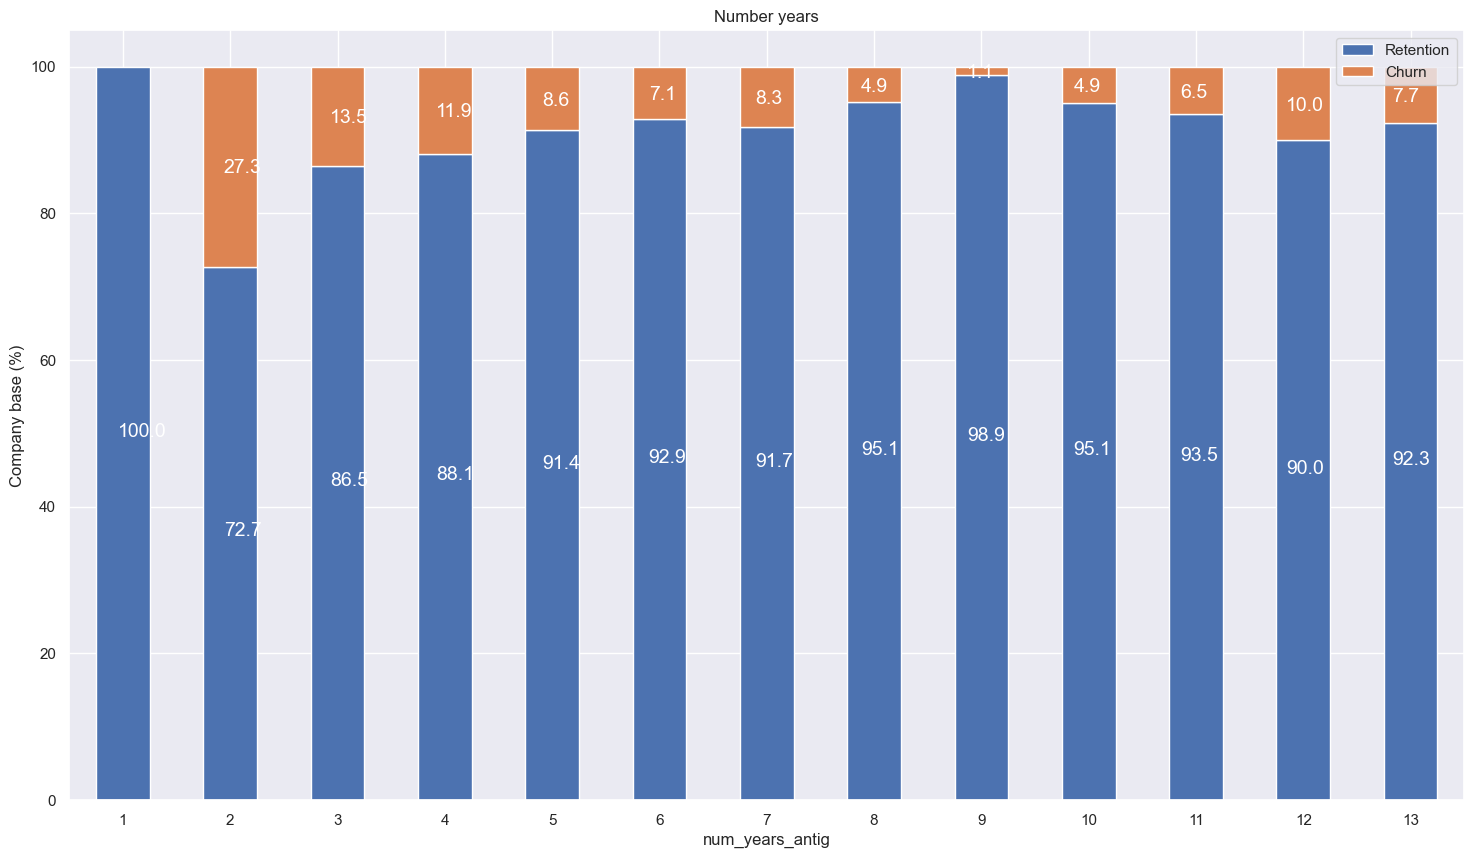

In [41]:
# Years antiquity churn %
years_antig_counts = (
    others
    .groupby(["num_years_antig", "churn"])["id"]
    .count()
    .unstack(level=1)
)

years_antig_percentage = years_antig_counts.div(years_antig_counts.sum(axis=1), axis=0) * 100
plot_stacked_bars(years_antig_percentage, "Number years")


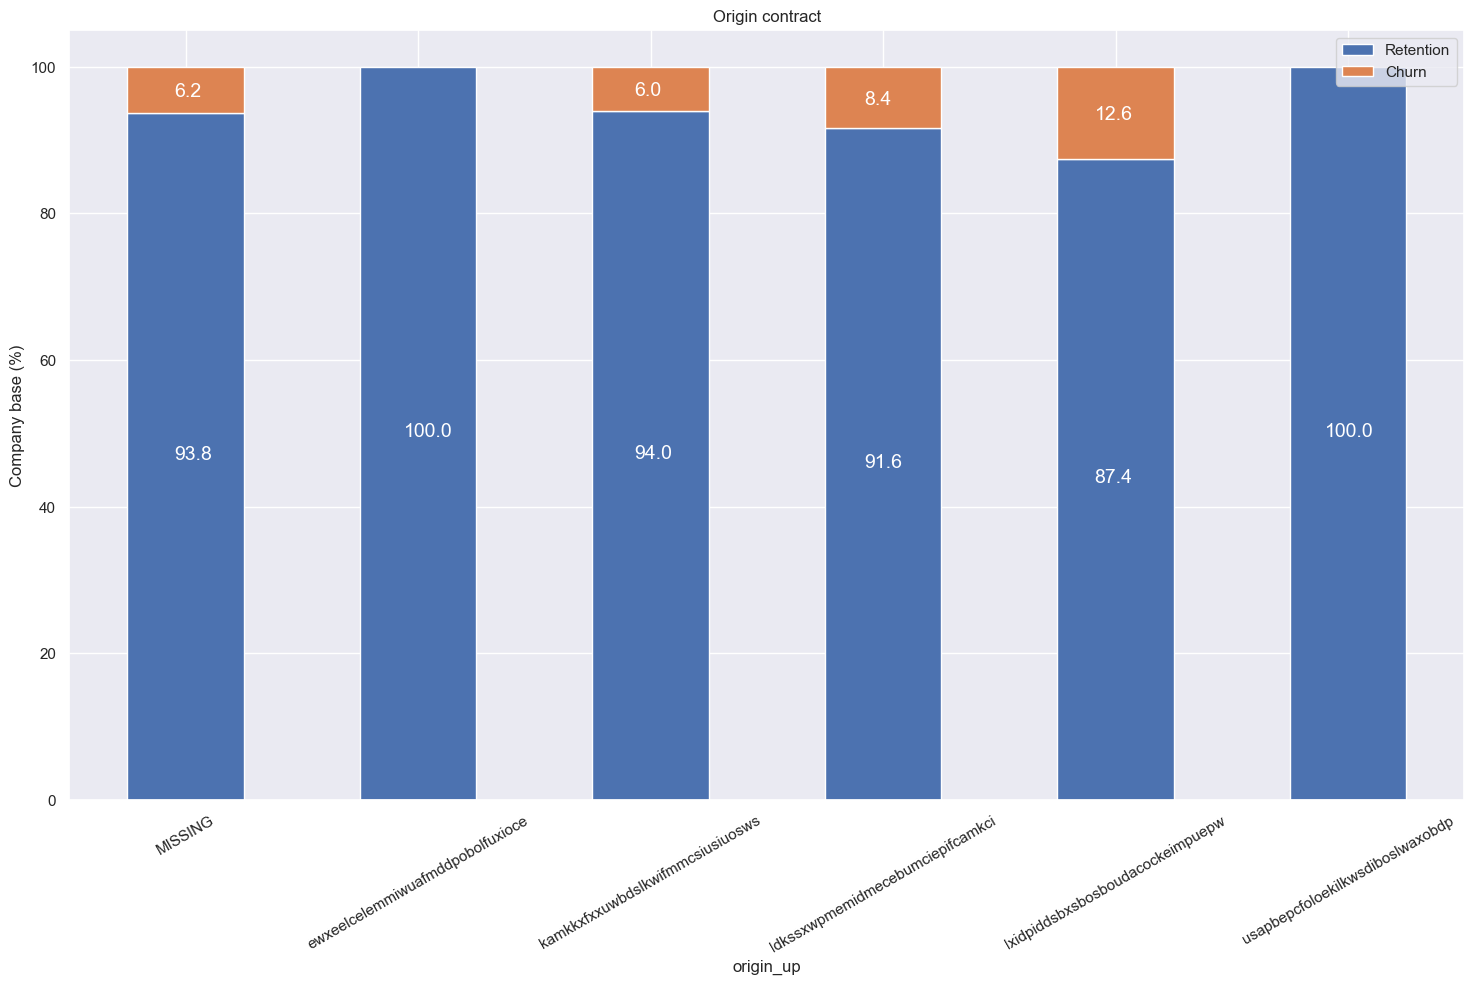

In [43]:
# Origin churn %
origin_counts = (
    others
    .groupby(["origin_up", "churn"])["id"]
    .count()
    .unstack(level=1)
)

origin_percentage = origin_counts.div(origin_counts.sum(axis=1), axis=0) * 100
plot_stacked_bars(origin_percentage, "Origin contract", rot=30)


# Feature Engineering

1. Import packages
2. Load cleaned data
3. Feature engineering


In [50]:
# Import and settings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [51]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

%matplotlib inline
sns.set(color_codes=True)

## 2. Load cleaned data

Load the post-EDA cleaned dataset and casting date fields that will be used to construct time based features.

In [52]:
# Loading and parsing dates
df = pd.read_csv("./clean_data_after_eda.csv")

date_cols = ["date_activ", "date_end", "date_modif_prod", "date_renewal"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d")

## 3. Feature engineering

### Difference between off-peak prices in December and preceding January

Recreating the dec/jan off-peak difference feature using monthly aggregation by company.



In [48]:
# Loading price data and parsing date
price_df = pd.read_csv("./price_data.csv")
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format="%Y-%m-%d")
price_df.shape
price_df.head(12)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0
5,038af19179925da21a25619c5a24b745,2015-06-01,0.149626,0.0,0.0,44.266930,0.0,0.0
6,038af19179925da21a25619c5a24b745,2015-07-01,0.150321,0.0,0.0,44.444710,0.0,0.0
7,038af19179925da21a25619c5a24b745,2015-08-01,0.145859,0.0,0.0,44.444710,0.0,0.0
8,038af19179925da21a25619c5a24b745,2015-09-01,0.145859,0.0,0.0,44.444710,0.0,0.0
9,038af19179925da21a25619c5a24b745,2015-10-01,0.145859,0.0,0.0,44.444710,0.0,0.0


In [47]:
# Dec vs Jan off-peak differences
monthly_price_by_id = (
    price_df
    .groupby(["id", "price_date"])
    .agg({"price_off_peak_var": "mean", "price_off_peak_fix": "mean"})
    .reset_index()
)

# First row per id corresponds to January (earliest month), last corresponds to December (latest month)
jan_prices = monthly_price_by_id.groupby("id").first().reset_index()
dec_prices = monthly_price_by_id.groupby("id").last().reset_index()

diff = pd.merge(
    dec_prices.rename(columns={"price_off_peak_var": "dec_1", "price_off_peak_fix": "dec_2"}),
    jan_prices.drop(columns="price_date"),
    on="id",
)

diff["offpeak_diff_dec_january_energy"] = diff["dec_1"] - diff["price_off_peak_var"]
diff["offpeak_diff_dec_january_power"] = diff["dec_2"] - diff["price_off_peak_fix"]

diff = diff[["id", "offpeak_diff_dec_january_energy", "offpeak_diff_dec_january_power"]]
diff.head()


,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


In [54]:
# Merging into modeling frame
df = pd.merge(df, diff, on="id")
df.head()


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1,0.020057,3.700961
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0,-0.003767,0.177779
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0,-0.004670,0.177779
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0,-0.004547,0.177779
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0,-0.006192,0.162916


## Average price changes across periods

Adding period level mean differences (off-peak vs peak vs mid-peak) to capture systematic pricing distribution.


In [56]:
# Mean prices per id
mean_prices = (
    price_df
    .groupby("id")
    .agg({
        "price_off_peak_var": "mean",
        "price_peak_var": "mean",
        "price_mid_peak_var": "mean",
        "price_off_peak_fix": "mean",
        "price_peak_fix": "mean",
        "price_mid_peak_fix": "mean",
    })
    .reset_index()
)
mean_prices.head()

,id,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,0002203ffbb812588b632b9e628cc38d,0.124338,0.103794,0.073160,40.701732,24.421038,16.280694
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.000000,0.000000,44.385450,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.000000,0.000000,45.319710,0.000000,0.000000
3,0010ee3855fdea87602a5b7aba8e42de,0.118757,0.098292,0.069032,40.647427,24.388455,16.258971
4,00114d74e963e47177db89bc70108537,0.147926,0.000000,0.000000,44.266930,0.000000,0.000000


In [57]:
# Mean period spreads
mean_prices["off_peak_peak_var_mean_diff"] = mean_prices["price_off_peak_var"] - mean_prices["price_peak_var"]
mean_prices["peak_mid_peak_var_mean_diff"] = mean_prices["price_peak_var"] - mean_prices["price_mid_peak_var"]
mean_prices["off_peak_mid_peak_var_mean_diff"] = mean_prices["price_off_peak_var"] - mean_prices["price_mid_peak_var"]

mean_prices["off_peak_peak_fix_mean_diff"] = mean_prices["price_off_peak_fix"] - mean_prices["price_peak_fix"]
mean_prices["peak_mid_peak_fix_mean_diff"] = mean_prices["price_peak_fix"] - mean_prices["price_mid_peak_fix"]
mean_prices["off_peak_mid_peak_fix_mean_diff"] = mean_prices["price_off_peak_fix"] - mean_prices["price_mid_peak_fix"]


In [58]:
# Merge mean spread features
spread_cols = [
    "id",
    "off_peak_peak_var_mean_diff",
    "peak_mid_peak_var_mean_diff",
    "off_peak_mid_peak_var_mean_diff",
    "off_peak_peak_fix_mean_diff",
    "peak_mid_peak_fix_mean_diff",
    "off_peak_mid_peak_fix_mean_diff",
]

df = pd.merge(df, mean_prices[spread_cols], on="id")
df.head()


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_mid_peak,churn,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power,off_peak_peak_var_mean_diff,peak_mid_peak_var_mean_diff,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,4.423670e+01,1,0.020057,3.700961,0.024038,0.034219,0.058257,18.590255,7.450670,26.040925
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000000e+00,0,-0.003767,0.177779,0.142485,0.007124,0.149609,44.311375,0.000000,44.311375
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000000e+00,0,-0.004670,0.177779,0.082090,0.088421,0.170512,44.385450,0.000000,44.385450
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000000e+00,0,-0.004547,0.177779,0.151210,0.000000,0.151210,44.400265,0.000000,44.400265
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,4.860000e-10,0,-0.006192,0.162916,0.020536,0.030773,0.051309,16.275263,8.137629,24.412893


## Max price changes across periods and months

Compute the maximum month-level period spread per company to represent worst-case price shocks.

In [59]:
# Monthly mean prices
mean_prices_by_month = (
    price_df
    .groupby(["id", "price_date"])
    .agg({
        "price_off_peak_var": "mean",
        "price_peak_var": "mean",
        "price_mid_peak_var": "mean",
        "price_off_peak_fix": "mean",
        "price_peak_fix": "mean",
        "price_mid_peak_fix": "mean",
    })
    .reset_index()
)

mean_prices_by_month.head()


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,0002203ffbb812588b632b9e628cc38d,2015-01-01,0.126098,0.103975,0.070232,40.565969,24.339581,16.226389
1,0002203ffbb812588b632b9e628cc38d,2015-02-01,0.126098,0.103975,0.070232,40.565969,24.339581,16.226389
2,0002203ffbb812588b632b9e628cc38d,2015-03-01,0.128067,0.105842,0.073773,40.728885,24.437330,16.291555
3,0002203ffbb812588b632b9e628cc38d,2015-04-01,0.128067,0.105842,0.073773,40.728885,24.437330,16.291555
4,0002203ffbb812588b632b9e628cc38d,2015-05-01,0.128067,0.105842,0.073773,40.728885,24.437330,16.291555


In [60]:
# Monthly period spreads
mean_prices_by_month["off_peak_peak_var_mean_diff"] = mean_prices_by_month["price_off_peak_var"] - mean_prices_by_month["price_peak_var"]
mean_prices_by_month["peak_mid_peak_var_mean_diff"] = mean_prices_by_month["price_peak_var"] - mean_prices_by_month["price_mid_peak_var"]
mean_prices_by_month["off_peak_mid_peak_var_mean_diff"] = mean_prices_by_month["price_off_peak_var"] - mean_prices_by_month["price_mid_peak_var"]

mean_prices_by_month["off_peak_peak_fix_mean_diff"] = mean_prices_by_month["price_off_peak_fix"] - mean_prices_by_month["price_peak_fix"]
mean_prices_by_month["peak_mid_peak_fix_mean_diff"] = mean_prices_by_month["price_peak_fix"] - mean_prices_by_month["price_mid_peak_fix"]
mean_prices_by_month["off_peak_mid_peak_fix_mean_diff"] = mean_prices_by_month["price_off_peak_fix"] - mean_prices_by_month["price_mid_peak_fix"]


In [61]:
# Max monthly spreads per id
max_diff_across_periods_months = (
    mean_prices_by_month
    .groupby("id")
    .agg({
        "off_peak_peak_var_mean_diff": "max",
        "peak_mid_peak_var_mean_diff": "max",
        "off_peak_mid_peak_var_mean_diff": "max",
        "off_peak_peak_fix_mean_diff": "max",
        "peak_mid_peak_fix_mean_diff": "max",
        "off_peak_mid_peak_fix_mean_diff": "max",
    })
    .reset_index()
    .rename(columns={
        "off_peak_peak_var_mean_diff": "off_peak_peak_var_max_monthly_diff",
        "peak_mid_peak_var_mean_diff": "peak_mid_peak_var_max_monthly_diff",
        "off_peak_mid_peak_var_mean_diff": "off_peak_mid_peak_var_max_monthly_diff",
        "off_peak_peak_fix_mean_diff": "off_peak_peak_fix_max_monthly_diff",
        "peak_mid_peak_fix_mean_diff": "peak_mid_peak_fix_max_monthly_diff",
        "off_peak_mid_peak_fix_mean_diff": "off_peak_mid_peak_fix_max_monthly_diff",
    })
)

max_diff_across_periods_months.head()

,id,off_peak_peak_var_max_monthly_diff,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff
0,0002203ffbb812588b632b9e628cc38d,0.022225,0.033743,0.055866,16.291555,8.145775,24.437330
1,0004351ebdd665e6ee664792efc4fd13,0.148405,0.000000,0.148405,44.444710,0.000000,44.444710
2,0010bcc39e42b3c2131ed2ce55246e3c,0.205742,0.000000,0.205742,45.944710,0.000000,45.944710
3,0010ee3855fdea87602a5b7aba8e42de,0.022581,0.031859,0.054440,16.291555,8.145775,24.437330
4,00114d74e963e47177db89bc70108537,0.149902,0.000000,0.149902,44.266931,0.000000,44.266931


In [62]:
# Merging max spread features
max_cols = [
    "id",
    "off_peak_peak_var_max_monthly_diff",
    "peak_mid_peak_var_max_monthly_diff",
    "off_peak_mid_peak_var_max_monthly_diff",
    "off_peak_peak_fix_max_monthly_diff",
    "peak_mid_peak_fix_max_monthly_diff",
    "off_peak_mid_peak_fix_max_monthly_diff",
]

df = pd.merge(df, max_diff_across_periods_months[max_cols], on="id")
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff,off_peak_peak_var_max_monthly_diff,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.058257,18.590255,7.450670,26.040925,0.060550,0.085483,0.146033,44.266930,8.145775,44.26693
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.149609,44.311375,0.000000,44.311375,0.151367,0.085483,0.151367,44.444710,0.000000,44.44471
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.170512,44.385450,0.000000,44.385450,0.084587,0.089162,0.172468,44.444710,0.000000,44.44471
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.151210,44.400265,0.000000,44.400265,0.153133,0.000000,0.153133,44.444710,0.000000,44.44471
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,0.051309,16.275263,8.137629,24.412893,0.022225,0.033743,0.055866,16.291555,8.145775,24.43733


### Tenure

Converting contract start/end into a coarse tenure in years to capture customer maturity effects as we received hints earlier.


In [63]:
# Tenure in years
df["date_activ"] = pd.to_datetime(df["date_activ"])
df["date_end"] = pd.to_datetime(df["date_end"])

df["tenure"] = (df["date_end"] - df["date_activ"]).dt.days // 365
df[["tenure", "churn"]].head()

,tenure,churn
0,3,1
1,7,0
2,6,0
3,6,0
4,6,0


In [66]:
# Tenure vs churn rate
df.groupby("tenure").agg({"churn": "mean"}).sort_values(by="tenure", ascending=False)*100

,churn
tenure,
13,9.523810
12,8.333333
11,5.978261
10,4.545455
9,1.250000
8,4.724409
7,7.547170
6,7.540703
5,9.199859


### Transform dates into month based features

Use a fixed reference date (Jan 1, 2016) and computing month deltas for activity length, time to contract end, and recency of modifications/renewals.

In [69]:
# Month delta helper
def convert_months(reference_date: datetime, frame: pd.DataFrame, column: str) -> pd.Series:
    """Return the number of whole months between `dataframe[column]` and a reference date."""
    dates = pd.to_datetime(frame[column])

    year_diff = reference_date.year - dates.dt.year
    month_diff = reference_date.month - dates.dt.month

    months = year_diff * 12 + month_diff
    months -= (reference_date.day < dates.dt.day).astype(int)

    return months


In [ ]:
# Creating month based time features
reference_date = datetime(2016, 1, 1)

df["months_activ"] = convert_months(reference_date, df, "date_activ")
df["months_to_end"] = -convert_months(reference_date, df, "date_end")
df["months_modif_prod"] = convert_months(reference_date, df, "date_modif_prod")
df["months_renewal"] = convert_months(reference_date, df, "date_renewal")

In [ ]:
# Dropping raw datetime columns now
drop_date_cols = ["date_activ", "date_end", "date_modif_prod", "date_renewal"]
df = df.drop(columns=drop_date_cols)
df.head()


In [74]:
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,...,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff,tenure,months_activ,months_to_end,months_modif_prod,months_renewal
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,0.00,0,0.0,1.78,0.114481,...,0.085483,0.146033,44.266930,8.145775,44.26693,3,30,6,2,6
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,189.95,0,0.0,16.27,0.145711,...,0.085483,0.151367,44.444710,0.000000,44.44471,7,76,8,76,4
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,47.96,0,0.0,38.72,0.165794,...,0.089162,0.172468,44.444710,0.000000,44.44471,6,68,4,68,8
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,240.04,0,0.0,19.83,0.146694,...,0.000000,0.153133,44.444710,0.000000,44.44471,6,69,3,69,9
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,445.75,526,0.0,131.73,0.116900,...,0.033743,0.055866,16.291555,8.145775,24.43733,6,71,3,71,9


### Transforming boolean data

Convert `has_gas` from string flags to a numeric binary indicator for modeling.

In [77]:
# has_gas encoding
df["has_gas"] = df["has_gas"].replace(["t", "f"], [1, 0])

### Transforming categorical data

One hot encoding `channel_sales` and `origin_up`, then dropping rare categories (count < 100) to avoid adding sparse, low signal predictors.


In [78]:
# One hot with rare category removing
cat_cols = ["channel_sales", "origin_up"]
min_count = 100

# Capturing preencoding counts to decide which categories to keep
value_counts = {col: df[col].value_counts() for col in cat_cols}

df = pd.get_dummies(df, columns=cat_cols, prefix=cat_cols, dtype=int)

for col in cat_cols:
    keep = set(value_counts[col][value_counts[col] >= min_count].index.astype(str))

    dummy_cols = [c for c in df.columns if c.startswith(f"{col}_")]
    drop_cols = [c for c in dummy_cols if c.split(f"{col}_", 1)[1] not in keep]

    df.drop(columns=drop_cols, inplace=True)

df.head()


,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_sales_MISSING,channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0,54946,0,0.00,0,0.0,1.78,0.114481,0.098142,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,4660,0,0,189.95,0,0.0,16.27,0.145711,0.000000,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,544,0,0,47.96,0,0.0,38.72,0.165794,0.087899,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,1584,0,0,240.04,0,0.0,19.83,0.146694,0.000000,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,4425,0,526,445.75,526,0.0,131.73,0.116900,0.100015,...,71,9,1,0,0,0,0,1,0,0


### Transforming skewed numerical features

Apply log10(x + 1) to positively skewed columns to compress extreme values while retaining ordering


In [80]:
# Log transforming skewed columns
skewed_cols = [
    "cons_12m",
    "cons_gas_12m",
    "cons_last_month",
    "forecast_cons_12m",
    "forecast_cons_year",
    "forecast_discount_energy",
    "forecast_meter_rent_12m",
    "forecast_price_energy_off_peak",
    "forecast_price_energy_peak",
    "forecast_price_pow_off_peak",
]

print("Before log transform:")
print(display(df[skewed_cols].describe()))

df[skewed_cols] = np.log10(df[skewed_cols] + 1)

print("\nAfter log transform:")
print(display(df[skewed_cols].describe()))


Before log transform:


,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak
count,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,4.223939,0.779244,2.264646,2.962177,1.784610,0.050918,1.517203,0.055766,0.020918,1.636058
std,0.884515,1.717071,1.769305,0.683592,1.584986,0.267388,0.571481,0.009438,0.020296,0.134237
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.754023,0.000000,0.000000,2.695477,0.000000,0.000000,1.235023,0.047796,0.000000,1.619163
50%,4.149727,0.000000,2.899547,3.046836,2.498311,0.000000,1.296555,0.058109,0.035085,1.656207
75%,4.610285,0.000000,3.529430,3.380716,3.242231,0.000000,2.120673,0.059316,0.040933,1.656207
max,6.792889,6.618528,5.887169,4.918575,5.243970,1.491362,2.778376,0.105157,0.077722,1.780075


None

After log transform:


,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak
count,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,0.710011,0.129048,0.420992,0.587677,0.350704,0.013653,0.387011,0.023550,0.008905,0.419956
std,0.092439,0.278711,0.310799,0.108446,0.303843,0.071665,0.117626,0.003892,0.008637,0.034065
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.677061,0.000000,0.000000,0.567671,0.000000,0.000000,0.349282,0.020277,0.000000,0.418163
50%,0.711784,0.000000,0.591014,0.607116,0.543858,0.000000,0.361077,0.024531,0.014976,0.424262
75%,0.748985,0.000000,0.656044,0.641545,0.627594,0.000000,0.494248,0.025026,0.017423,0.424262
max,0.891698,0.881871,0.838041,0.772217,0.795461,0.396437,0.577305,0.043424,0.032507,0.444057


None


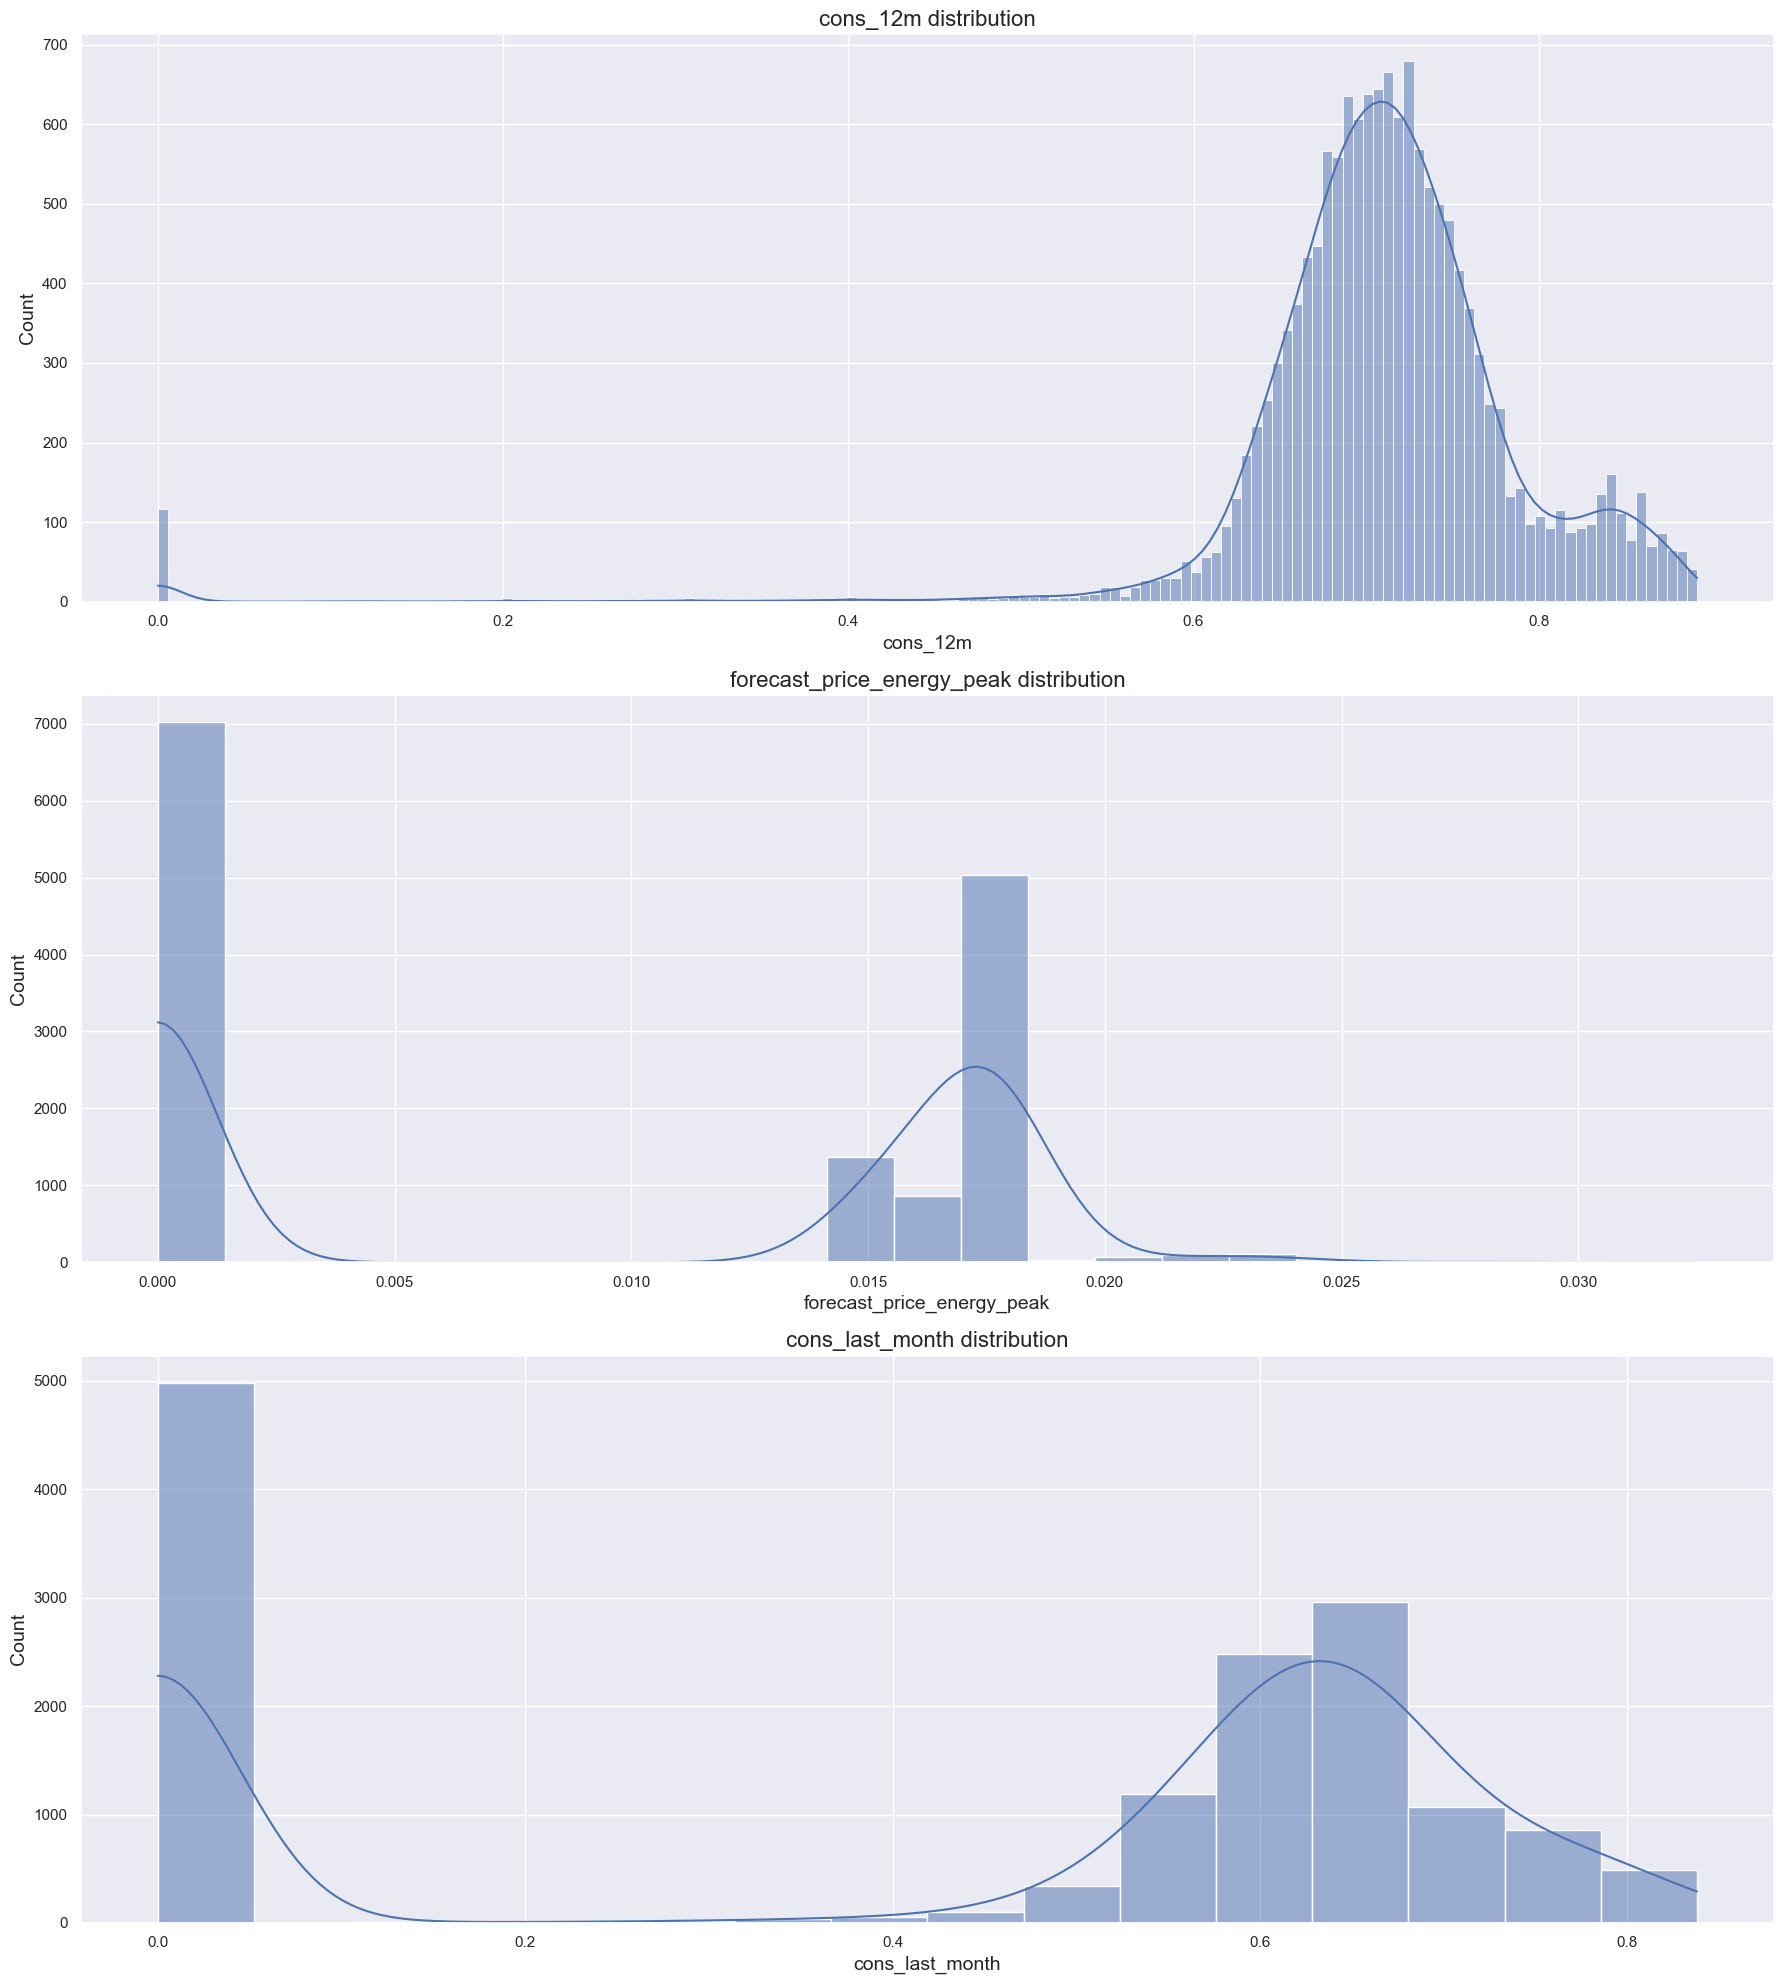

In [81]:
# Visual check for a few transformed columns
plot_cols = ["cons_12m", "forecast_price_energy_peak", "cons_last_month"]

fig, axs = plt.subplots(nrows=len(plot_cols), figsize=(18, 20))

for ax, col in zip(axs, plot_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"{col} distribution", fontsize=16)
    ax.set_xlabel(col, fontsize=14)
    ax.set_ylabel("Count", fontsize=14)

plt.tight_layout()
plt.show()


### Correlations

Computing correlations to spot multicollinearity and decide which redundant predictors to drop before modeling.


In [82]:
# Correlation matrix 
correlation = df.drop(columns=["id"]).corr()
correlation.iloc[:5, :5]

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year
cons_12m,1.000000,0.137272,0.447870,0.555933,0.267478
cons_gas_12m,0.137272,1.000000,0.122209,0.074860,0.067369
cons_last_month,0.447870,0.122209,1.000000,0.204438,0.822980
forecast_cons_12m,0.555933,0.074860,0.204438,1.000000,0.270735
forecast_cons_year,0.267478,0.067369,0.822980,0.270735,1.000000


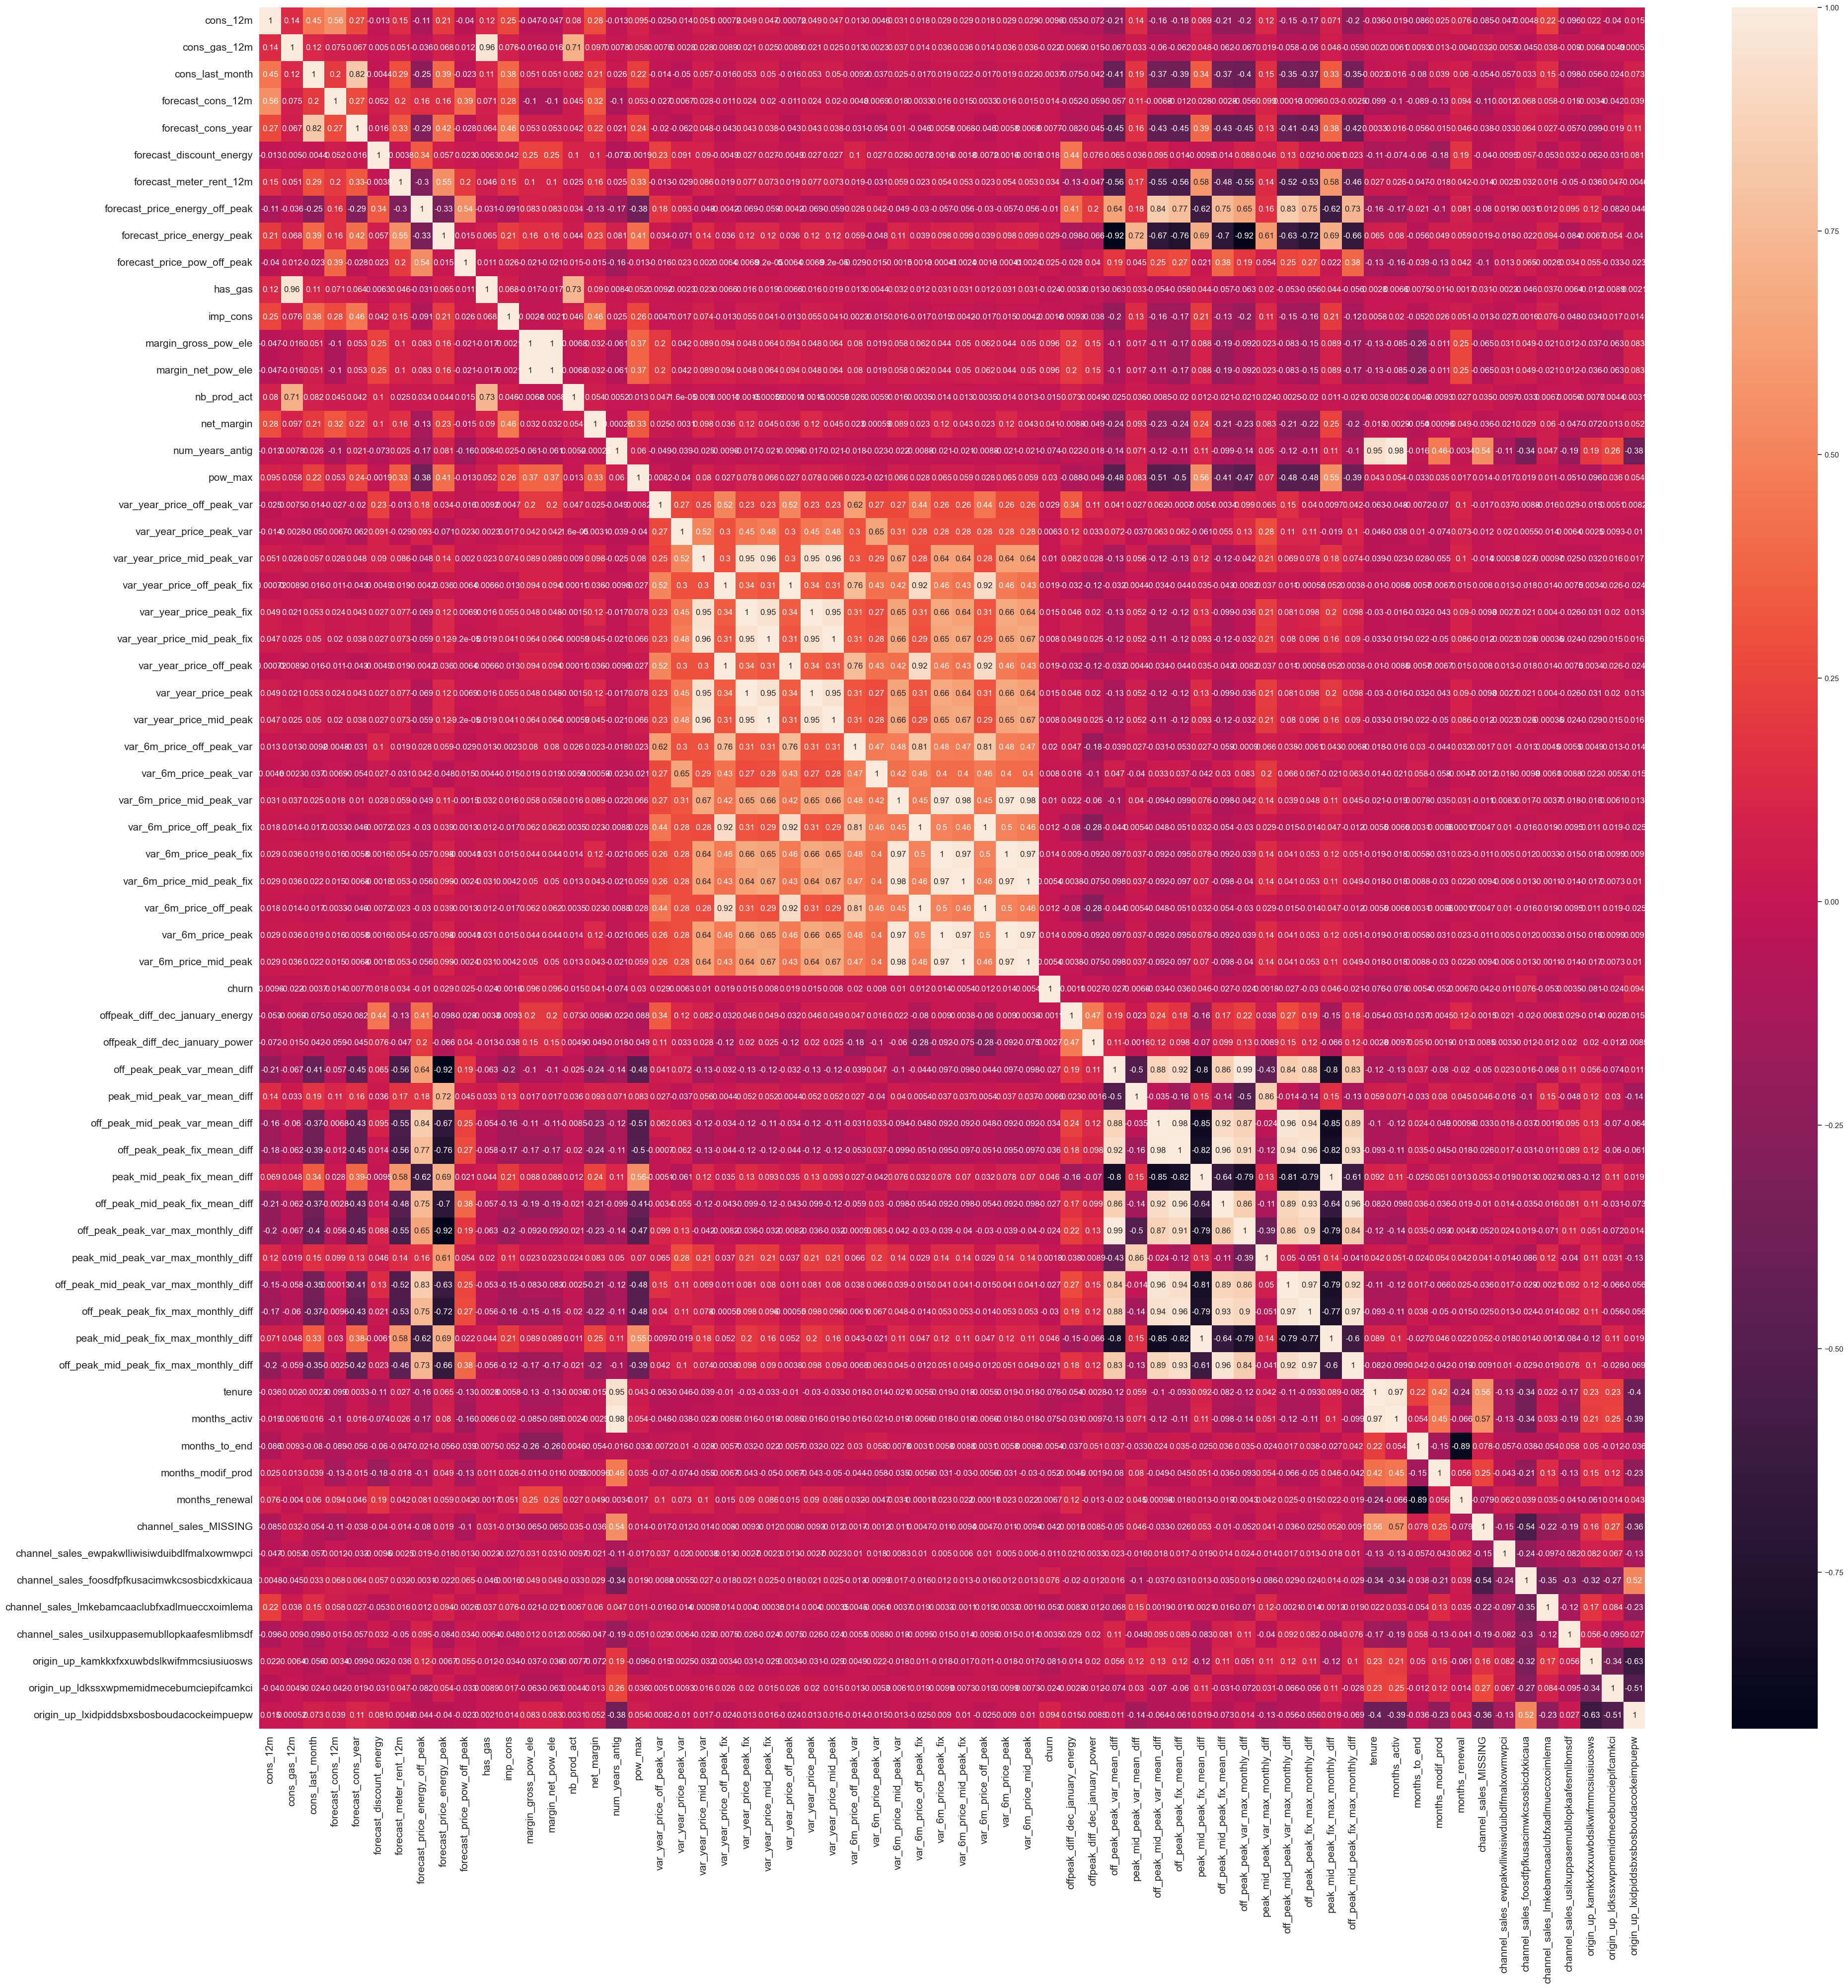

In [83]:
# Correlation heatmap
plt.figure(figsize=(45, 45))
sns.heatmap(
    correlation,
    xticklabels=correlation.columns.values,
    yticklabels=correlation.columns.values,
    annot=True,
    annot_kws={"size": 12},
)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()


In [84]:
# Dropping highly redundant features
df = df.drop(columns=["num_years_antig", "forecast_cons_year"])
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_sales_MISSING,channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,0.758908,0.000000,0.000000,0.0,0.159581,0.019977,0.017308,0.418163,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,0.669175,0.000000,0.000000,0.515996,0.0,0.349723,0.024927,0.000000,0.424262,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,0.572453,0.000000,0.000000,0.429727,0.0,0.414808,0.028010,0.015606,0.424262,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,0.623252,0.000000,0.000000,0.529185,0.0,0.365243,0.025079,0.000000,0.424262,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,0.667080,0.000000,0.570754,0.562301,0.0,0.494568,0.020367,0.017617,0.418163,...,71,9,1,0,0,0,0,1,0,0


# Modelling

1. Import packages
2. Load modeling dataset
3. Train Random Forest
4. Evaluate and interpret


In [85]:
# Warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [86]:
# Modelling libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline
sns.set(color_codes=True)


## 2. Load data

Loading the feature engineered dataset used for predictions


In [88]:
# Load modelling data
df = pd.read_csv("./data_for_predictions.csv")

In [89]:
df.head(2)

,Unnamed: 0,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.0,0.00000,0.0,0.444045,0.114481,0.098142,...,2,6,0,0,1,0,0,0,0,1
1,1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.0,2.28092,0.0,1.237292,0.145711,0.000000,...,76,4,1,0,0,0,0,1,0,0


In [90]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_modif_prod,months_renewal,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.114481,0.098142,40.606701,...,2,6,0,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.145711,0.000000,44.311378,...,76,4,1,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.165794,0.087899,44.311378,...,68,8,0,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.146694,0.000000,44.311378,...,69,9,0,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.116900,0.100015,40.606701,...,71,9,1,0,0,0,0,1,0,0


## 3. Modelling

Splittng into train/test (75/25) and training a Random Forest classifier.

In [91]:
# Train/test split
train_df = df.copy()

y = train_df["churn"]
X = train_df.drop(columns=["id", "churn"])

print(X.shape)
print(y.shape)


(14606, 61)
(14606,)


In [92]:
# Sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 61)
(10954,)
(3652, 61)
(3652,)


In [93]:
# Model training
model = RandomForestClassifier(n_estimators=1000, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=1000, random_state=42)

## Evaluation

Compute confusion matrix components and report accuracy, precision, and recall.

In [94]:
# Predictions and confusion matrix
predictions = model.predict(X_test)
tn, fp, fn, tp = metrics.confusion_matrix(y_test, predictions).ravel()

tn, fp, fn, tp

(np.int64(3283), np.int64(3), np.int64(349), np.int64(17))

In [95]:
# Class balance in test labels
y_test.value_counts()

churn
0    3286
1     366
Name: count, dtype: int64

In [96]:
# Metrics report
print(f"True positives: {tp}")
print(f"False positives: {fp}")
print(f"True negatives: {tn}")
print(f"False negatives: {fn}\n")

print(f"Accuracy:  {metrics.accuracy_score(y_test, predictions)}")
print(f"Precision: {metrics.precision_score(y_test, predictions)}")
print(f"Recall:    {metrics.recall_score(y_test, predictions)}")


True positives: 17
False positives: 3
True negatives: 3283
False negatives: 349

Accuracy:  0.9036144578313253
Precision: 0.85
Recall:    0.04644808743169399


## Model understanding

Extracting feature importances and visualizing them to see which predictors dominate splits across the forest.

In [97]:
# Feature importance table
feature_importances = (
    pd.DataFrame({"features": X_train.columns, "importance": model.feature_importances_})
    .sort_values(by="importance", ascending=True)
    .reset_index(drop=True)
)

feature_importances.head()

,features,importance
0,peak_mid_peak_fix_max_monthly_diff,0.001047
1,forecast_discount_energy,0.001333
2,var_6m_price_mid_peak_fix,0.001944
3,var_6m_price_peak_fix,0.002091
4,channel_ewpakwlliwisiwduibdlfmalxowmwpci,0.002592


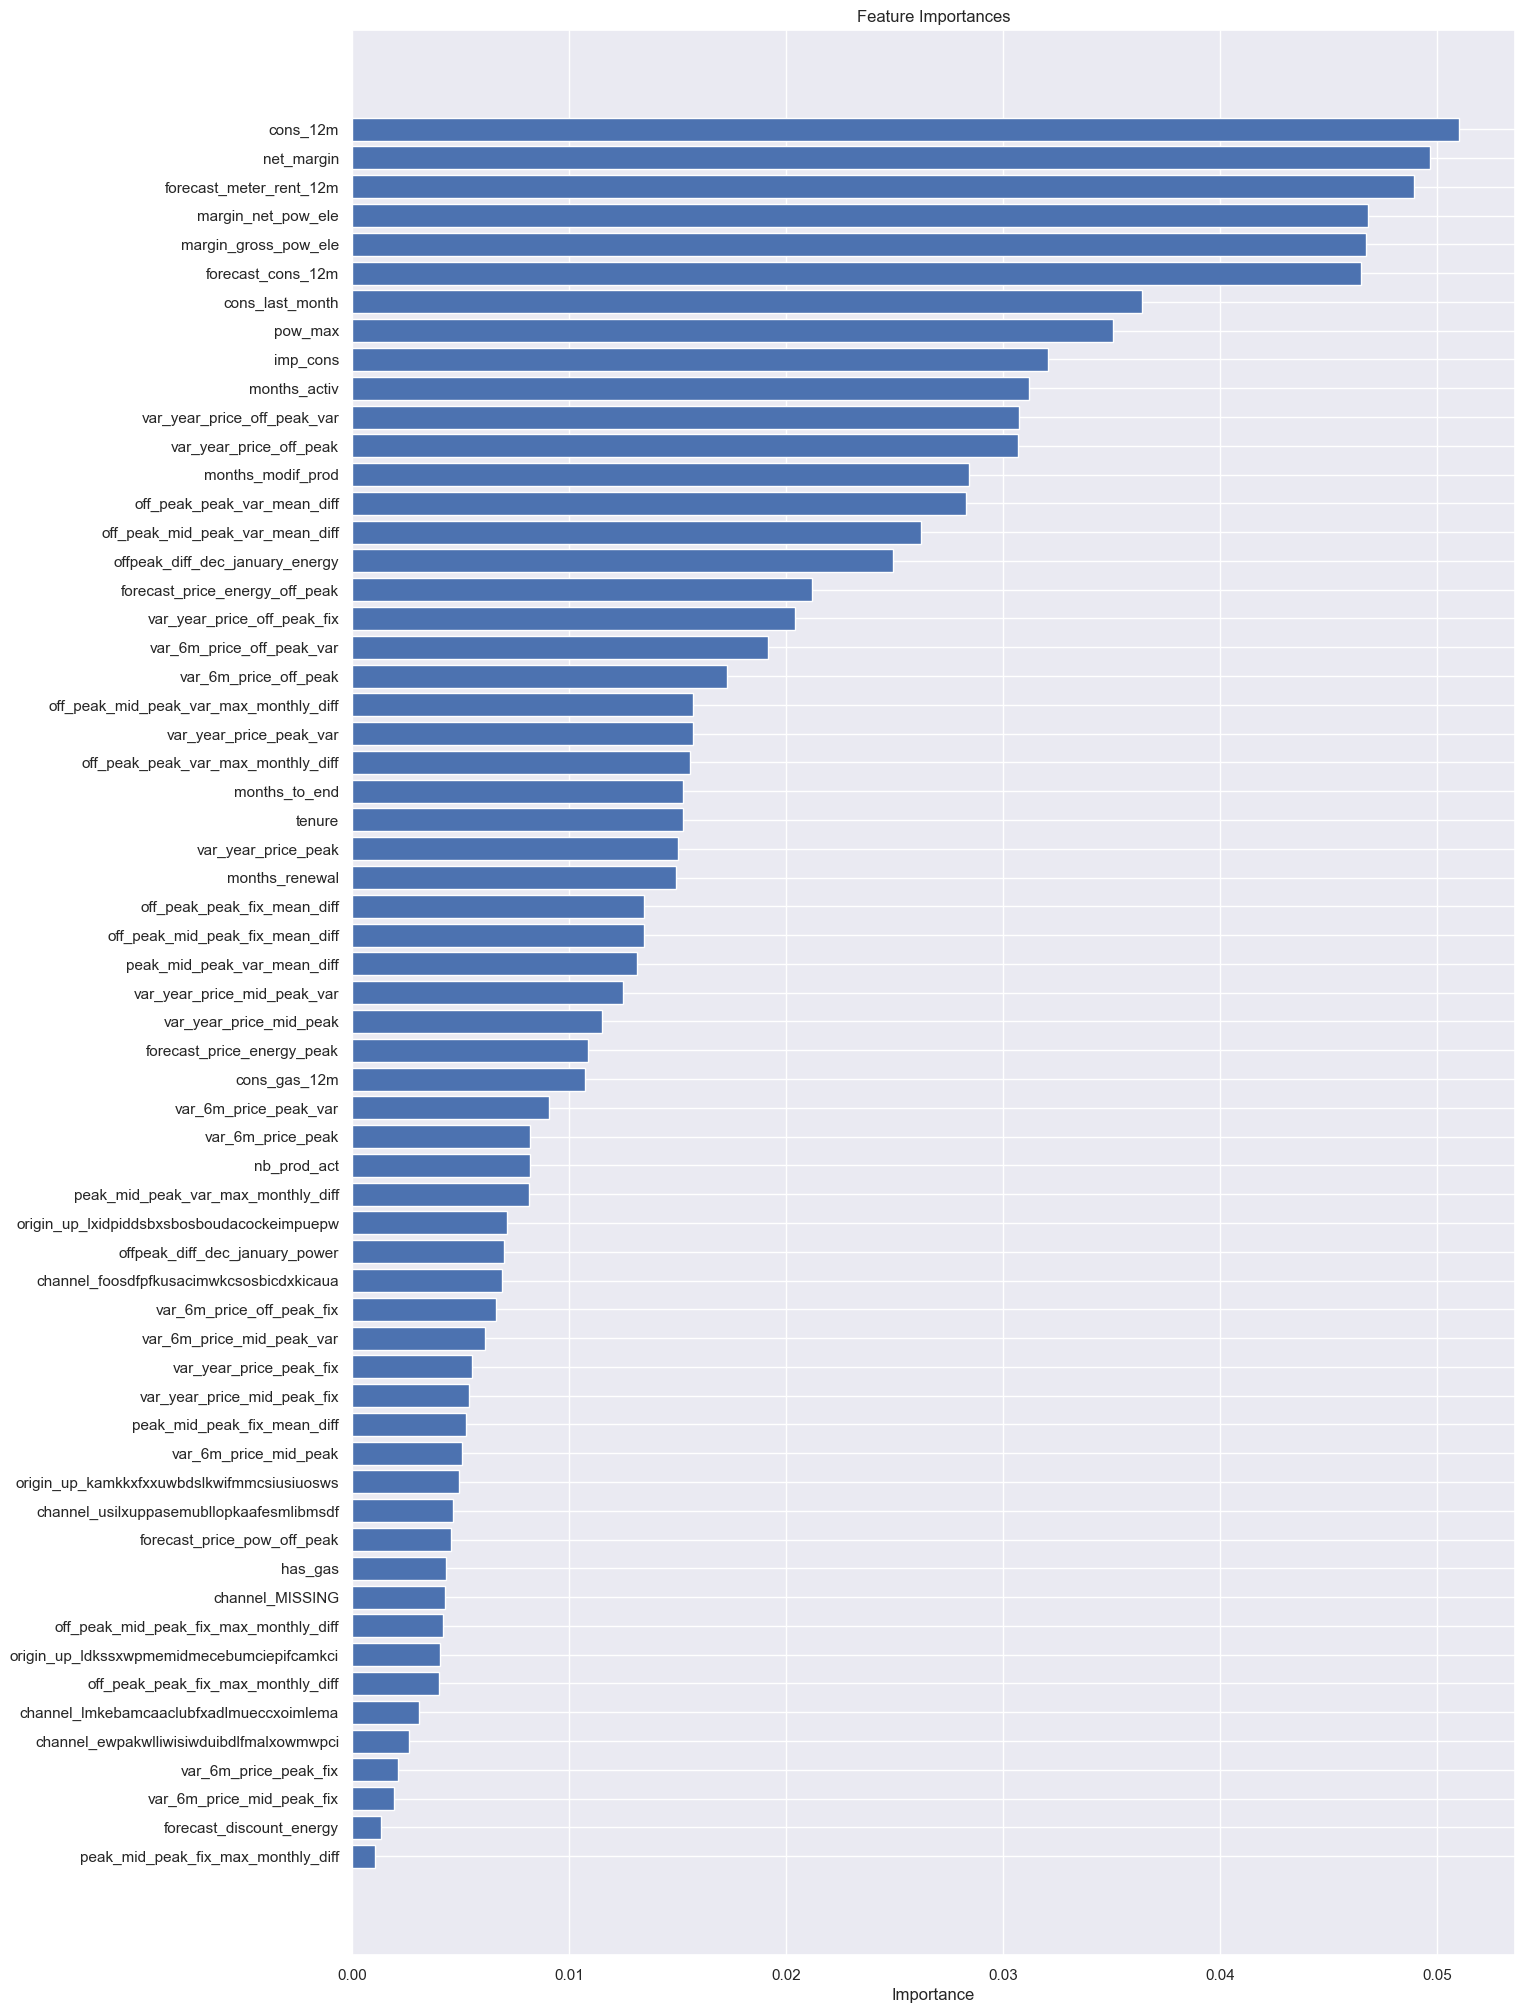

In [98]:
# Plotting feature importances
plt.figure(figsize=(15, 25))
plt.title("Feature Importances")
plt.barh(range(len(feature_importances)), feature_importances["importance"], align="center")
plt.yticks(range(len(feature_importances)), feature_importances["features"])
plt.xlabel("Importance")
plt.show()


## Out of sample scoring output

Attaching predictions and churn probabilities to the test sample and export for later review.

In [99]:
# Probabilities, export
proba_predictions = model.predict_proba(X_test)
probabilities = proba_predictions[:, 1]

X_test_out = X_test.reset_index(drop=True).copy()
X_test_out["churn"] = predictions.tolist()
X_test_out["churn_probability"] = probabilities.tolist()

X_test_out.to_csv("out_of_sample_data_with_predictions.csv", index=False)
X_test_out.head()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,...,channel_MISSING,channel_ewpakwlliwisiwduibdlfmalxowmwpci,channel_foosdfpfkusacimwkcsosbicdxkicaua,channel_lmkebamcaaclubfxadlmueccxoimlema,channel_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw,churn,churn_probability
0,4.173390,4.193598,3.165541,3.168368,0.0,2.073828,0.114667,0.099548,40.606701,1,...,0,0,1,0,0,0,0,1,0,0.105
1,4.075036,0.000000,3.003461,3.305998,30.0,1.255031,0.198096,0.000000,46.305378,0,...,0,0,1,0,0,0,0,1,0,0.197
2,3.848435,0.000000,0.000000,2.756568,0.0,1.289366,0.141434,0.000000,44.311378,0,...,0,0,1,0,0,0,0,1,0,0.048
3,4.345433,0.000000,0.000000,3.516690,0.0,1.304921,0.142996,0.000000,44.311378,0,...,0,0,1,0,0,0,0,1,0,0.075
4,4.185655,0.000000,3.355834,3.208148,0.0,2.123067,0.120372,0.103487,40.606701,0,...,0,0,1,0,0,0,1,0,0,0.038
